In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler

In [2]:
df=pd.read_csv("pre_final_database.csv")

In [5]:
df.describe()

,catcher_id,jobma_catcher_title,jobma_catcher_status,jobma_catcher_type,is_premium,jobma_verified,subscription_status,sub_user,live_interview_credit,pre_recorded_credit,...,credit_given,currency_val,times_of_subscription,kits_count,position_created,number_of_invitations,pitchers_counts,def_interview_counts,interview_counts,ai_interview_counts
count,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,...,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000
mean,4768.240369,0.234943,0.908663,0.922590,0.378188,0.999096,1.887864,279.376379,1.423505,3.383758,...,49.328269,1.977976,1.986616,2.605173,1.512751,8.709893,6.570266,3.347260,0.170194,0.013384
std,2431.388564,0.777744,0.301610,0.267265,0.484979,0.030061,0.317847,1927.332416,13.675515,135.205973,...,291.776292,8.306666,4.597021,128.021540,18.617189,102.554300,240.300559,37.065864,3.278246,0.903944
min,92.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2774.000000,0.000000,1.000000,1.000000,0.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4794.000000,0.000000,1.000000,1.000000,0.000000,1.000000,2.000000,5.000000,1.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6914.000000,0.000000,1.000000,1.000000,1.000000,1.000000,2.000000,103.000000,1.000000,1.000000,...,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,9445.000000,8.000000,1.000000,1.000000,1.000000,1.000000,2.000000,140000.000000,1000.000000,9999.990000,...,10000.000000,71.870000,238.000000,9504.000000,825.000000,3396.000000,17640.000000,1069.000000,150.000000,67.000000


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
catcher_id,5529.0,4768.240369,2.431389e+03,92.0,2774.00,4794.0,6914.0,9445.00
jobma_catcher_title,5529.0,0.234943,7.777441e-01,0.0,0.00,0.0,0.0,8.00
jobma_catcher_status,5529.0,0.908663,3.016102e-01,-1.0,1.00,1.0,1.0,1.00
jobma_catcher_type,5529.0,0.922590,2.672651e-01,0.0,1.00,1.0,1.0,1.00
is_premium,5529.0,0.378188,4.849787e-01,0.0,0.00,0.0,1.0,1.00
jobma_verified,5529.0,0.999096,3.006108e-02,0.0,1.00,1.0,1.0,1.00
subscription_status,5529.0,1.887864,3.178470e-01,0.0,2.00,2.0,2.0,2.00
sub_user,5529.0,279.376379,1.927332e+03,0.0,1.00,5.0,103.0,140000.00
live_interview_credit,5529.0,1.423505,1.367551e+01,0.0,1.00,1.0,1.0,1000.00
pre_recorded_credit,5529.0,3.383758,1.352060e+02,0.0,1.00,1.0,1.0,9999.99


In [105]:
df.describe(include='all')

,catcher_id,jobma_catcher_title,jobma_catcher_otype,jobma_catcher_status,jobma_catcher_type,is_premium,jobma_verified,subscription_status,sub_user,per_sub_user,...,currency_val,times_of_subscription,kits_count,position_created,number_of_invitations,pitchers_counts,def_interview_counts,interview_counts,ai_interview_counts,subscription_bin
count,5529.000000,5529.000000,5529,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529,...,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529
unique,NaN,NaN,7,NaN,NaN,NaN,NaN,NaN,NaN,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(-13933.333, 1393333.3]"
freq,NaN,NaN,5297,NaN,NaN,NaN,NaN,NaN,NaN,3098,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5510
mean,4768.240369,0.234943,NaN,0.908663,0.922590,0.378188,0.999096,1.887864,279.376379,NaN,...,1.977976,1.986616,2.605173,1.512751,8.709893,6.570266,3.347260,0.170194,0.013384,NaN
std,2431.388564,0.777744,NaN,0.301610,0.267265,0.484979,0.030061,0.317847,1927.332416,NaN,...,8.306666,4.597021,128.021540,18.617189,102.554300,240.300559,37.065864,3.278246,0.903944,NaN
min,92.000000,0.000000,NaN,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,2774.000000,0.000000,NaN,1.000000,1.000000,0.000000,1.000000,2.000000,1.000000,NaN,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,4794.000000,0.000000,NaN,1.000000,1.000000,0.000000,1.000000,2.000000,5.000000,NaN,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,6914.000000,0.000000,NaN,1.000000,1.000000,1.000000,1.000000,2.000000,103.000000,NaN,...,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN


In [99]:
df.corr(numeric_only=True)

,catcher_id,jobma_catcher_title,jobma_catcher_status,jobma_catcher_type,is_premium,jobma_verified,subscription_status,sub_user,live_interview_credit,pre_recorded_credit,...,credit_given,currency_val,times_of_subscription,kits_count,position_created,number_of_invitations,pitchers_counts,def_interview_counts,interview_counts,ai_interview_counts
catcher_id,1.000000,-0.035389,0.129206,0.252906,-0.621303,-0.032328,-0.360213,-0.079656,-0.018921,0.016790,...,0.220420,-0.144965,0.056769,-0.015107,-0.034153,-0.007959,-0.026898,0.002234,-0.026953,-0.013644
jobma_catcher_title,-0.035389,1.000000,-0.071220,0.076197,0.057424,-0.052809,-0.050738,0.036912,-0.008472,-0.005022,...,0.034915,-0.035796,-0.019005,-0.003683,0.008807,-0.018117,-0.006592,-0.014841,-0.002631,-0.003959
jobma_catcher_status,0.129206,-0.071220,1.000000,0.260110,-0.138529,-0.009112,0.087502,-0.046047,0.008681,0.005039,...,0.000197,0.035876,-0.071857,0.003095,-0.005897,-0.010103,0.001011,-0.012648,0.001454,0.004485
jobma_catcher_type,0.252906,0.076197,0.260110,1.000000,-0.090905,-0.008715,-0.078778,-0.033508,0.010011,0.005208,...,0.048976,0.035899,0.046714,0.005620,0.017140,0.023699,0.003673,0.012009,0.014420,0.004289
is_premium,-0.621303,0.057424,-0.138529,-0.090905,1.000000,0.011055,0.124952,0.096171,-0.005530,-0.010882,...,-0.102198,0.071125,0.048845,0.020901,0.058560,0.054446,0.026904,0.063447,0.035059,0.016099
jobma_verified,-0.032328,-0.052809,-0.009112,-0.008715,0.011055,1.000000,0.027250,-0.001977,0.000932,0.000441,...,0.003024,0.003542,0.002530,-0.002725,-0.003373,-0.007596,-0.000004,-0.003615,-0.000274,0.000445
subscription_status,-0.360213,-0.050738,0.087502,-0.078778,0.124952,0.027250,1.000000,0.009521,0.008243,-0.037786,...,-0.143246,0.042640,-0.221771,-0.043628,-0.050383,-0.107217,-0.012580,-0.120053,-0.059631,-0.041367
sub_user,-0.079656,0.036912,-0.046047,-0.033508,0.096171,-0.001977,0.009521,1.000000,-0.003923,-0.002392,...,-0.020425,0.015139,-0.006164,0.005071,0.012200,-0.000465,0.006060,0.004484,0.011972,0.004809
live_interview_credit,-0.018921,-0.008472,0.008681,0.010011,-0.005530,0.000932,0.008243,-0.003923,1.000000,0.100685,...,-0.005320,0.000464,-0.000075,0.000442,-0.000510,-0.000947,-0.000601,-0.001564,0.001535,0.000522
pre_recorded_credit,0.016790,-0.005022,0.005039,0.005208,-0.010882,0.000441,-0.037786,-0.002392,0.100685,1.000000,...,-0.000413,-0.001683,0.000935,0.000087,-0.001037,-0.000993,-0.000368,-0.000901,-0.000551,0.000136


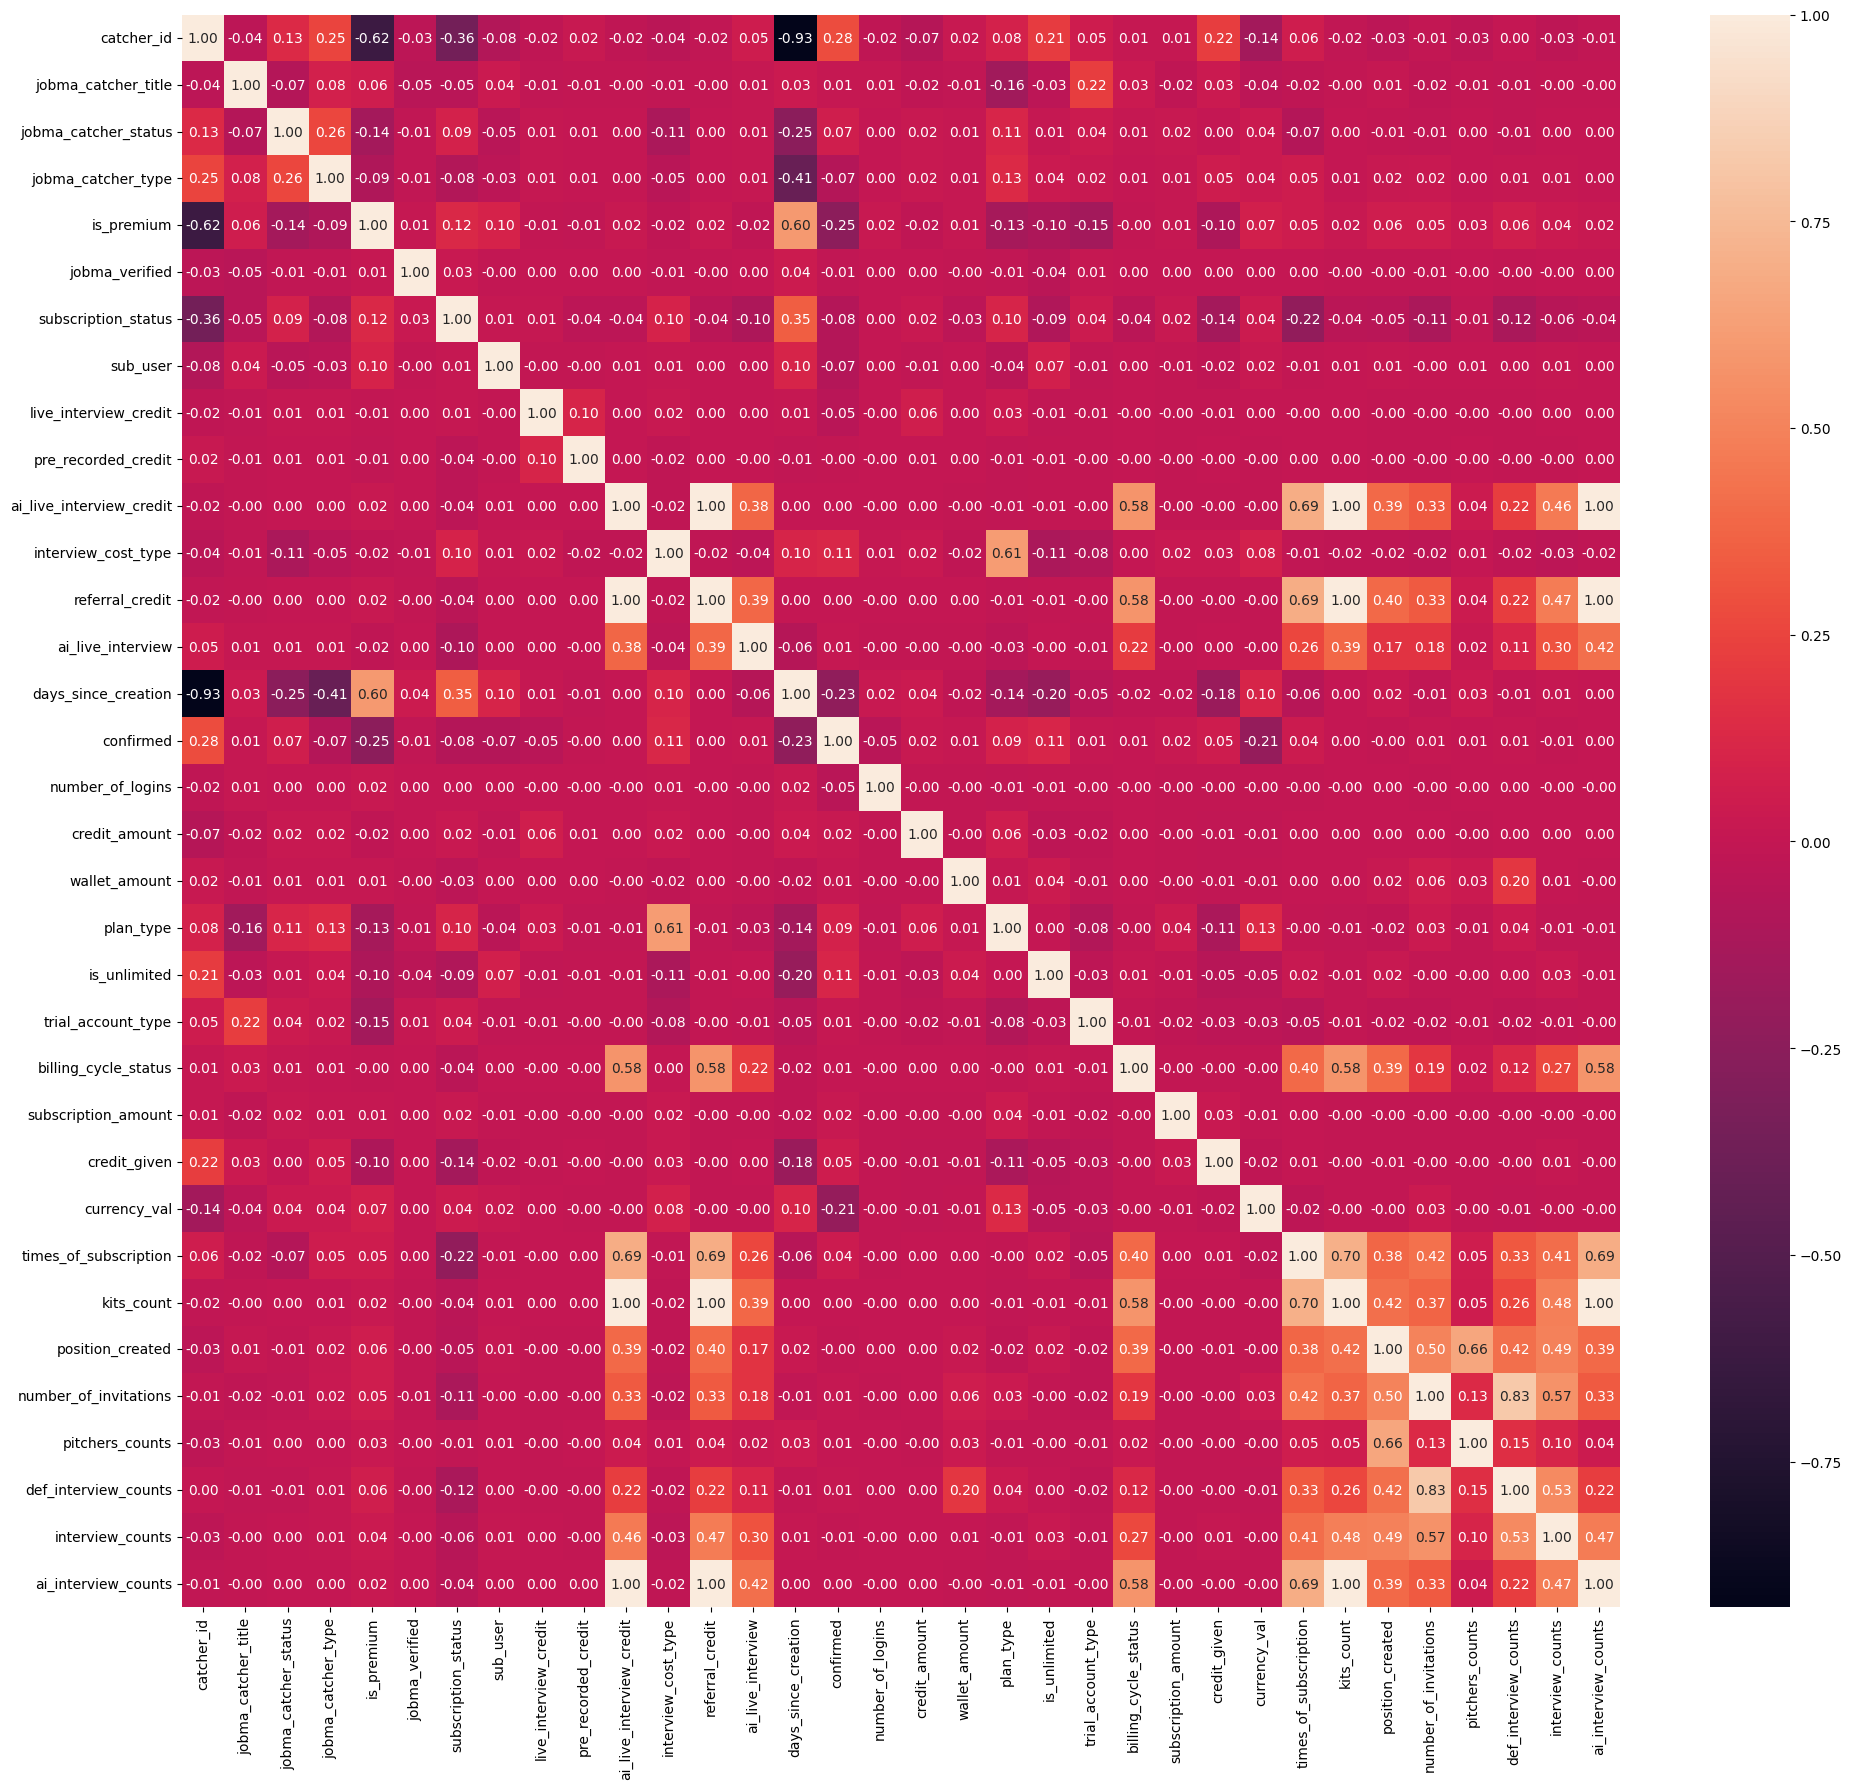

In [101]:
plt.figure(figsize=(20, 18))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f')
plt.tight_layout()
plt.show()

# Visualising Sub_user

In [59]:
df['sub_user'].value_counts().tail(20)

sub_user
37        1
123       1
35        1
130       1
64        1
63        1
65        1
145       1
107       1
120       1
19        1
113       1
116       1
140000    1
29        1
24        1
73        1
53        1
23        1
1001      1
Name: count, dtype: int64

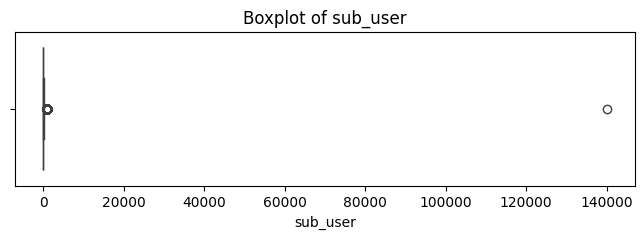

In [62]:
plt.figure(figsize=(8, 2))
sns.boxplot(x=df['sub_user'])
plt.title('Boxplot of sub_user')
plt.show()


<Axes: xlabel='sub_user', ylabel='count'>

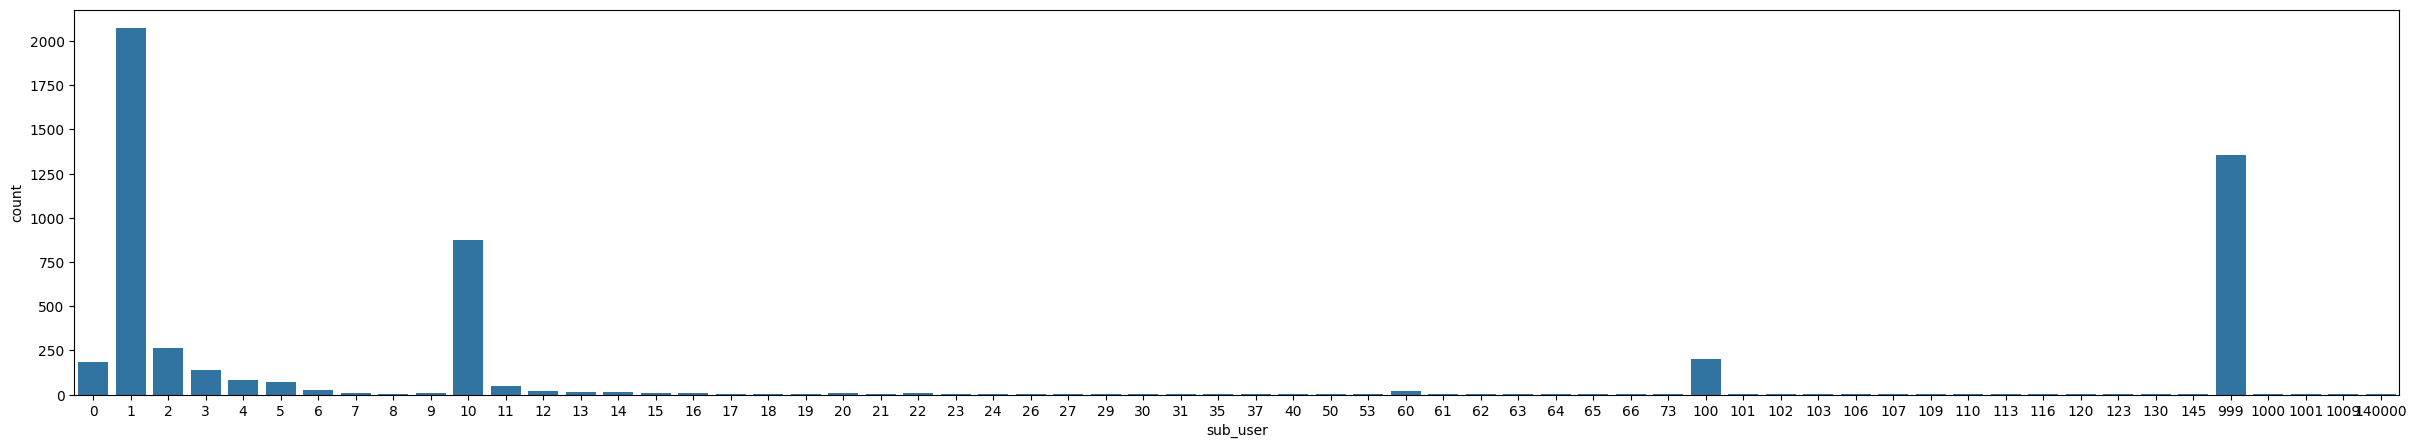

In [11]:
plt.figure(figsize=(30,5))
sns.countplot(x=df['sub_user'])

<Axes: xlabel='live_interview_credit'>

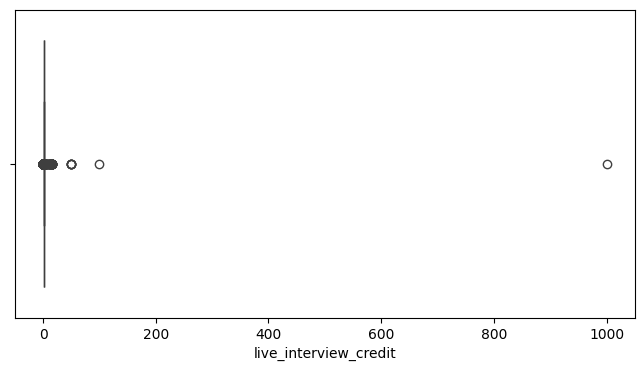

In [61]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['live_interview_credit'])

<Axes: xlabel='live_interview_credit', ylabel='count'>

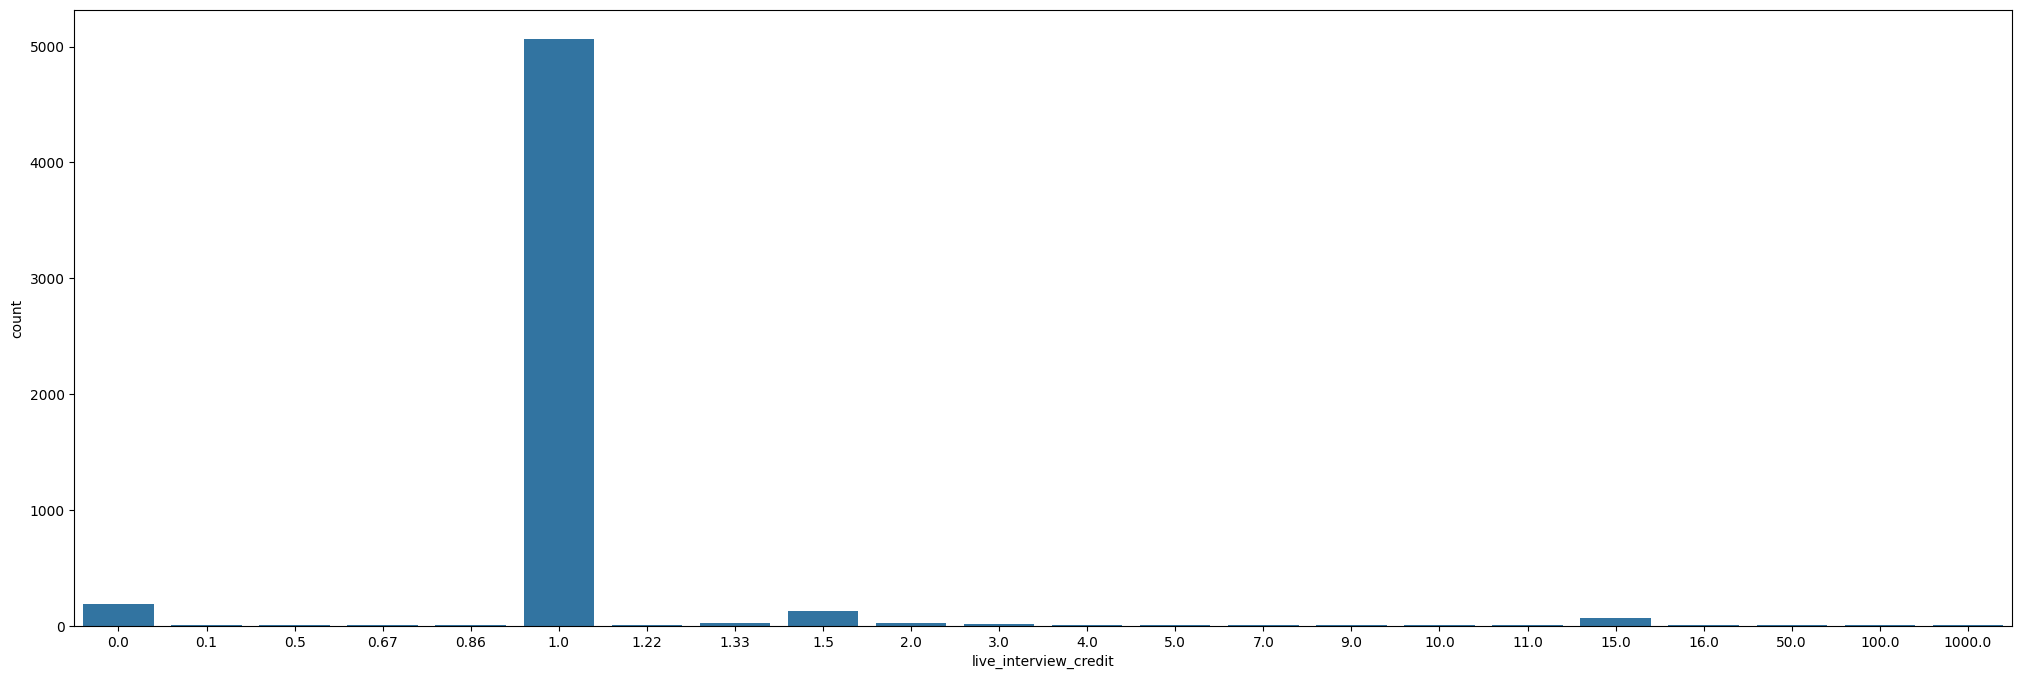

In [68]:
plt.figure(figsize=(25,8))
sns.countplot(x=df['live_interview_credit'])

In [69]:
#Pre_recorded_credit

<Axes: xlabel='pre_recorded_credit'>

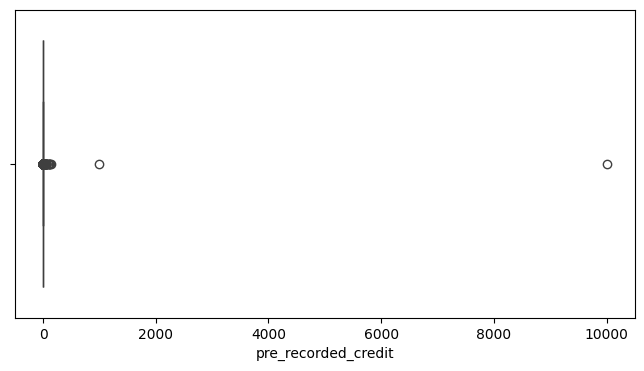

In [74]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['pre_recorded_credit'])

<Axes: xlabel='pre_recorded_credit', ylabel='count'>

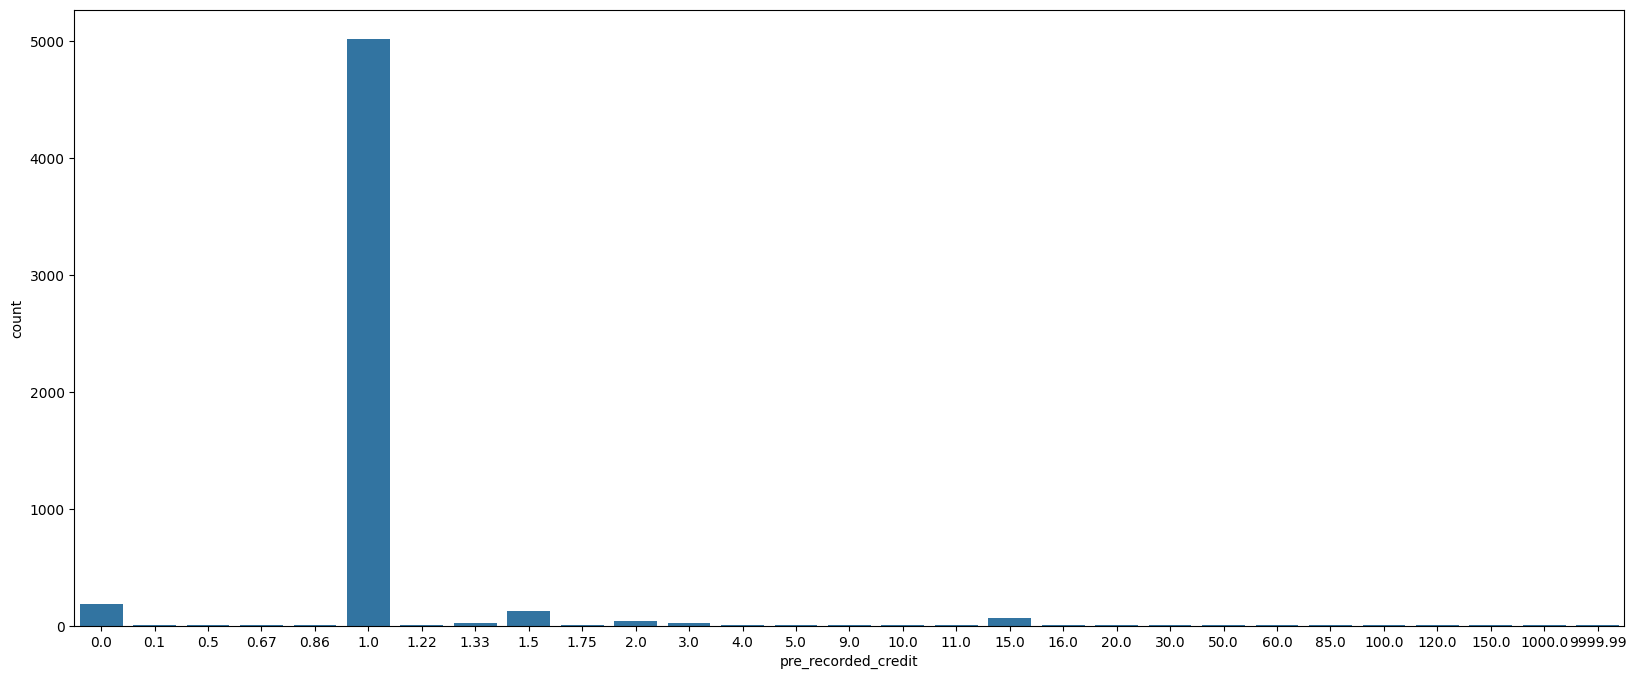

In [76]:
plt.figure(figsize=(20,8))
sns.countplot(x=df['pre_recorded_credit'])

In [77]:
#Credit_given

<Axes: xlabel='credit_given'>

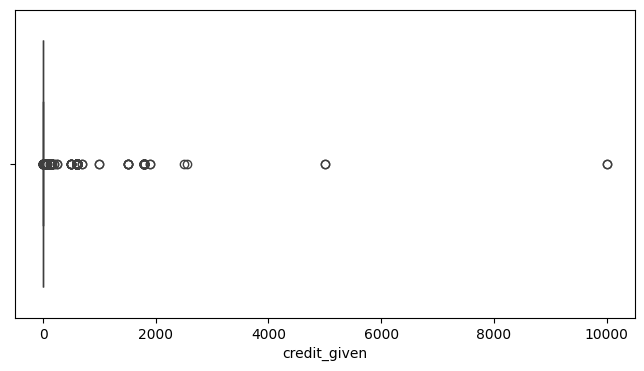

In [78]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['credit_given'])

<Axes: xlabel='credit_given', ylabel='count'>

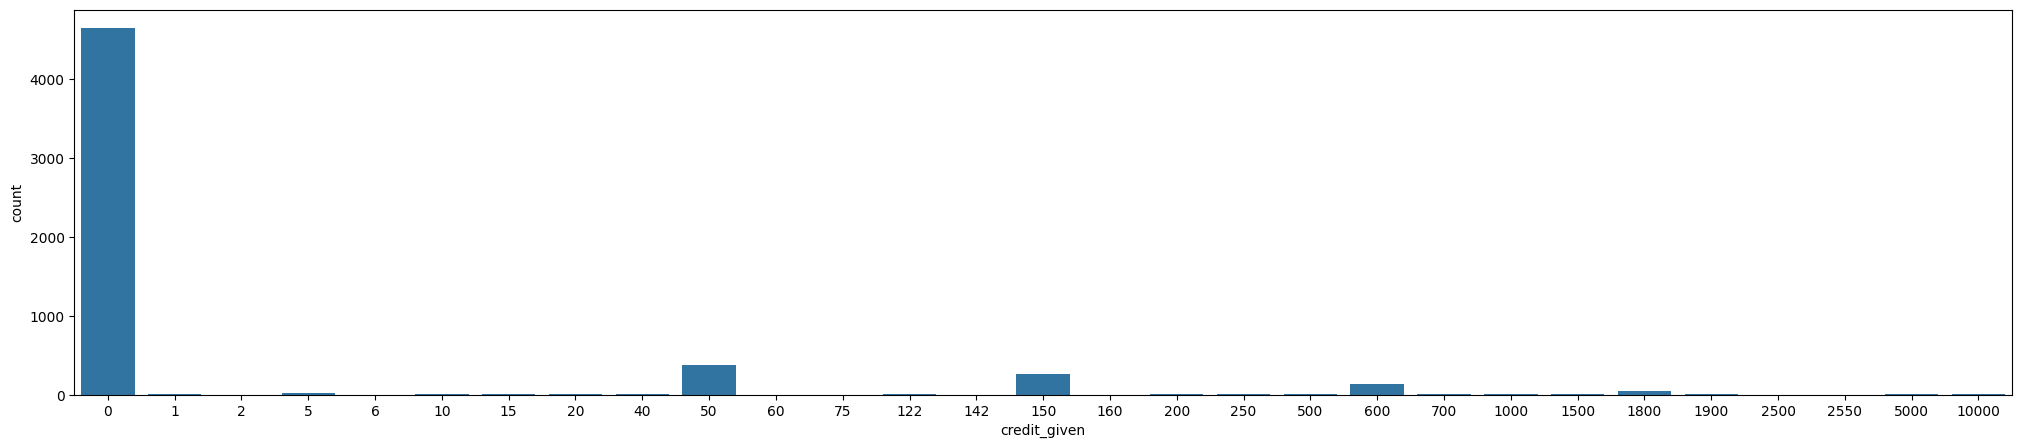

In [79]:
plt.figure(figsize=(25,5))
sns.countplot(x=df['credit_given'])

In [ ]:
#now currency_val

<Axes: xlabel='currency_val'>

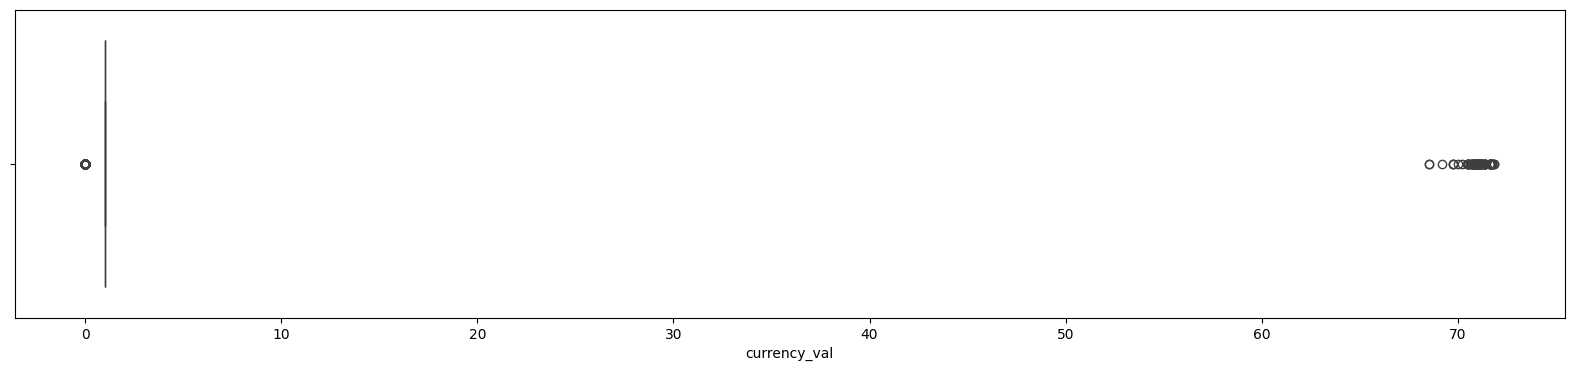

In [82]:
plt.figure(figsize=(20,4))
sns.boxplot(x=df['currency_val'])

<Axes: xlabel='currency_val', ylabel='count'>

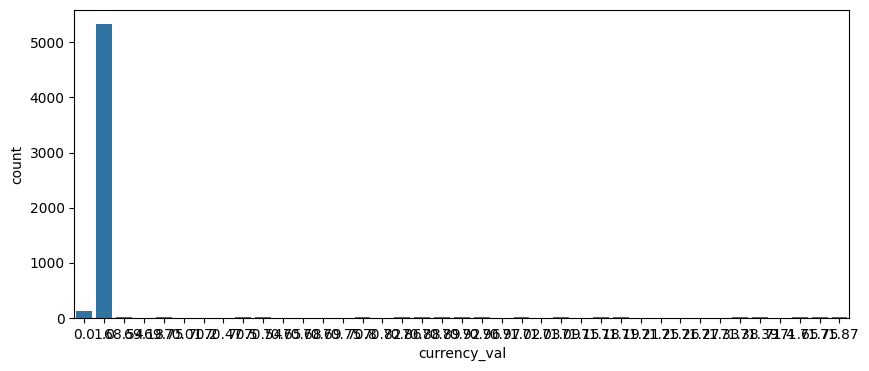

In [104]:
plt.figure(figsize=(10,4))
sns.countplot(x=df['currency_val'])

In [ ]:
#referral_credit

<Axes: xlabel='referral_credit'>

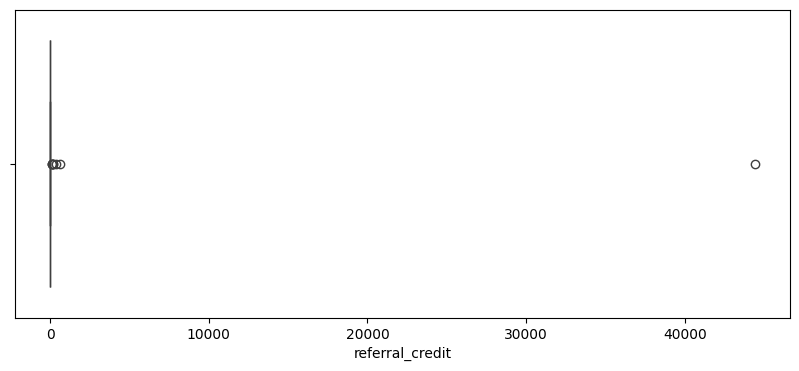

In [87]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['referral_credit'])

<Axes: xlabel='referral_credit', ylabel='count'>

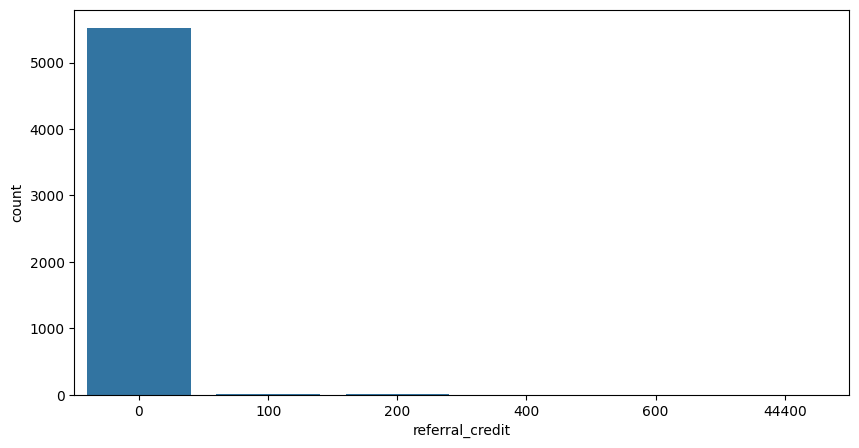

In [102]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['referral_credit'])

<Axes: xlabel='jobma_catcher_title', ylabel='Count'>

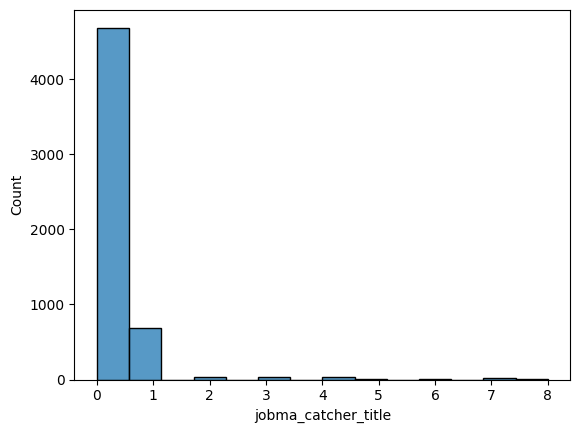

In [17]:
sns.histplot(data=df['jobma_catcher_title'])

<Axes: xlabel='days_since_creation', ylabel='Count'>

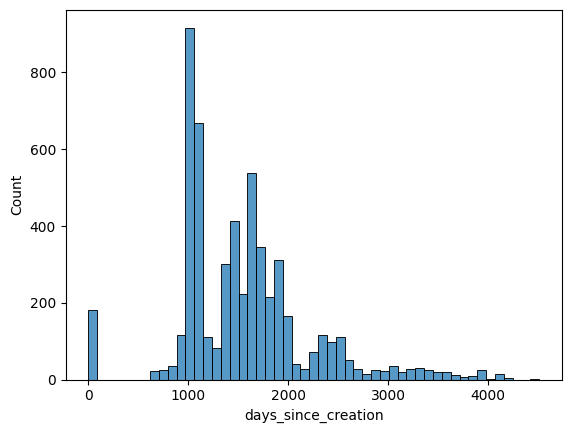

In [91]:
sns.histplot(data=df['days_since_creation'])

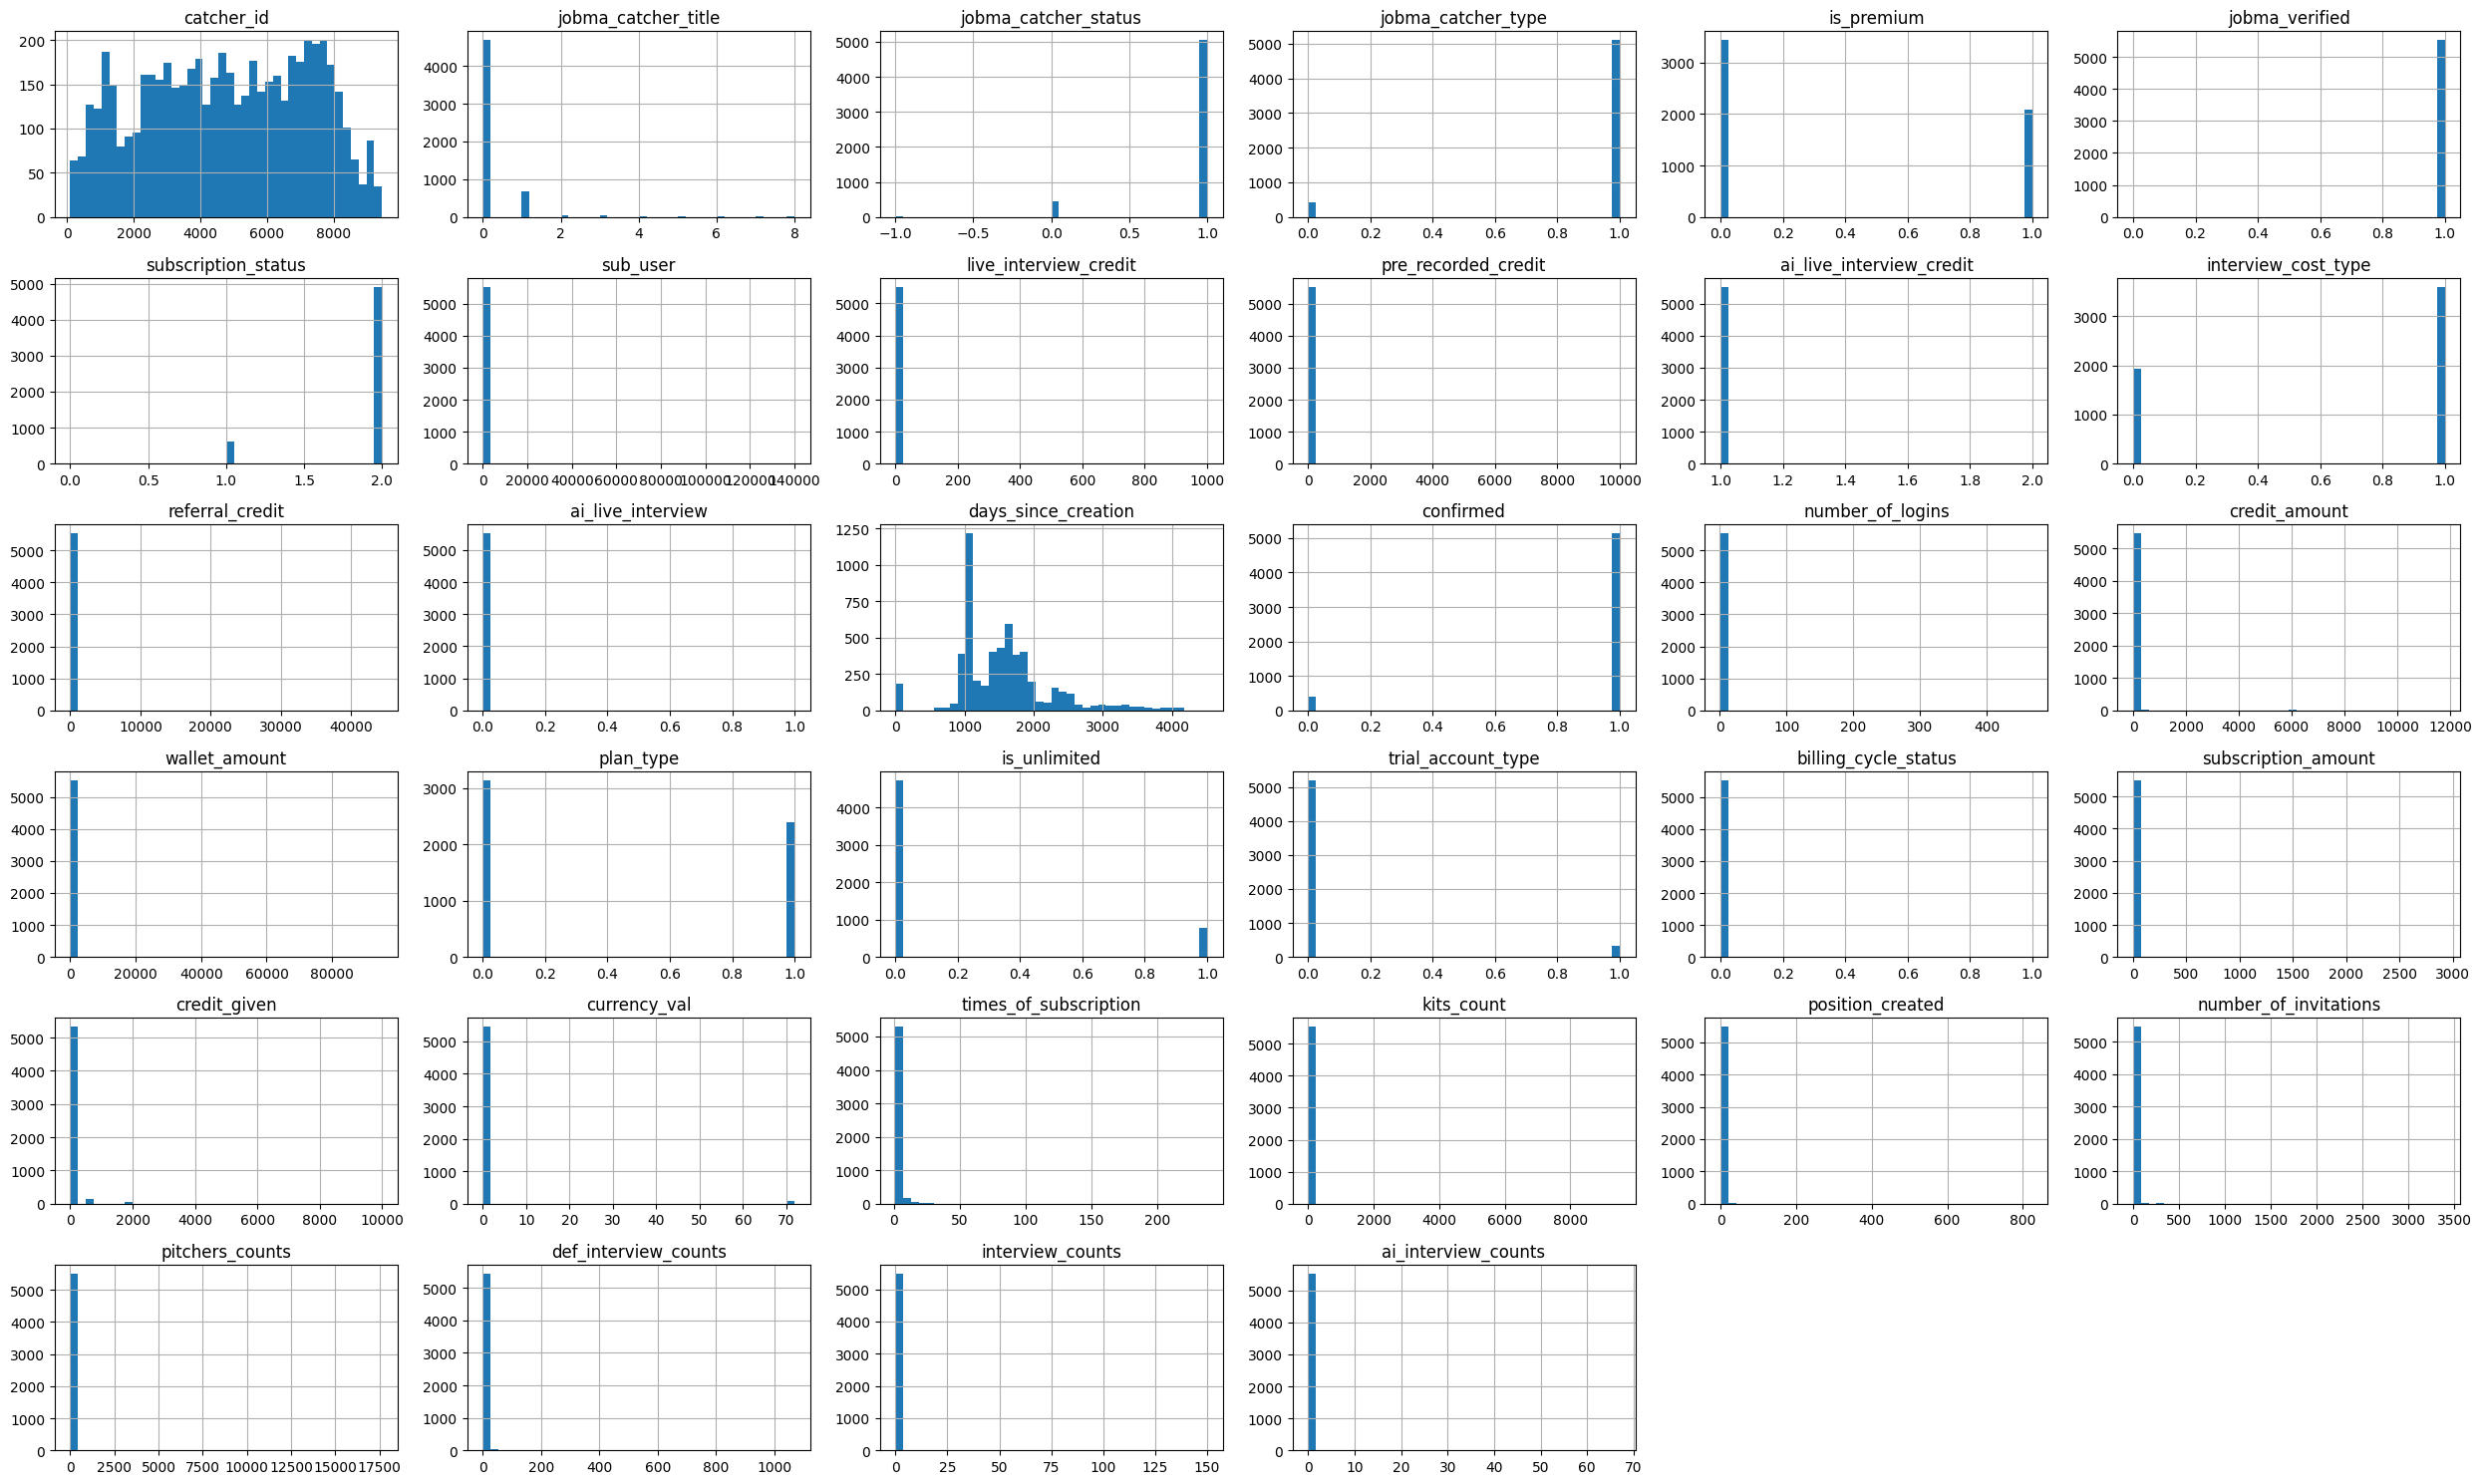

In [93]:
df.hist(bins=40, figsize=(25, 15))
plt.tight_layout()
plt.show()

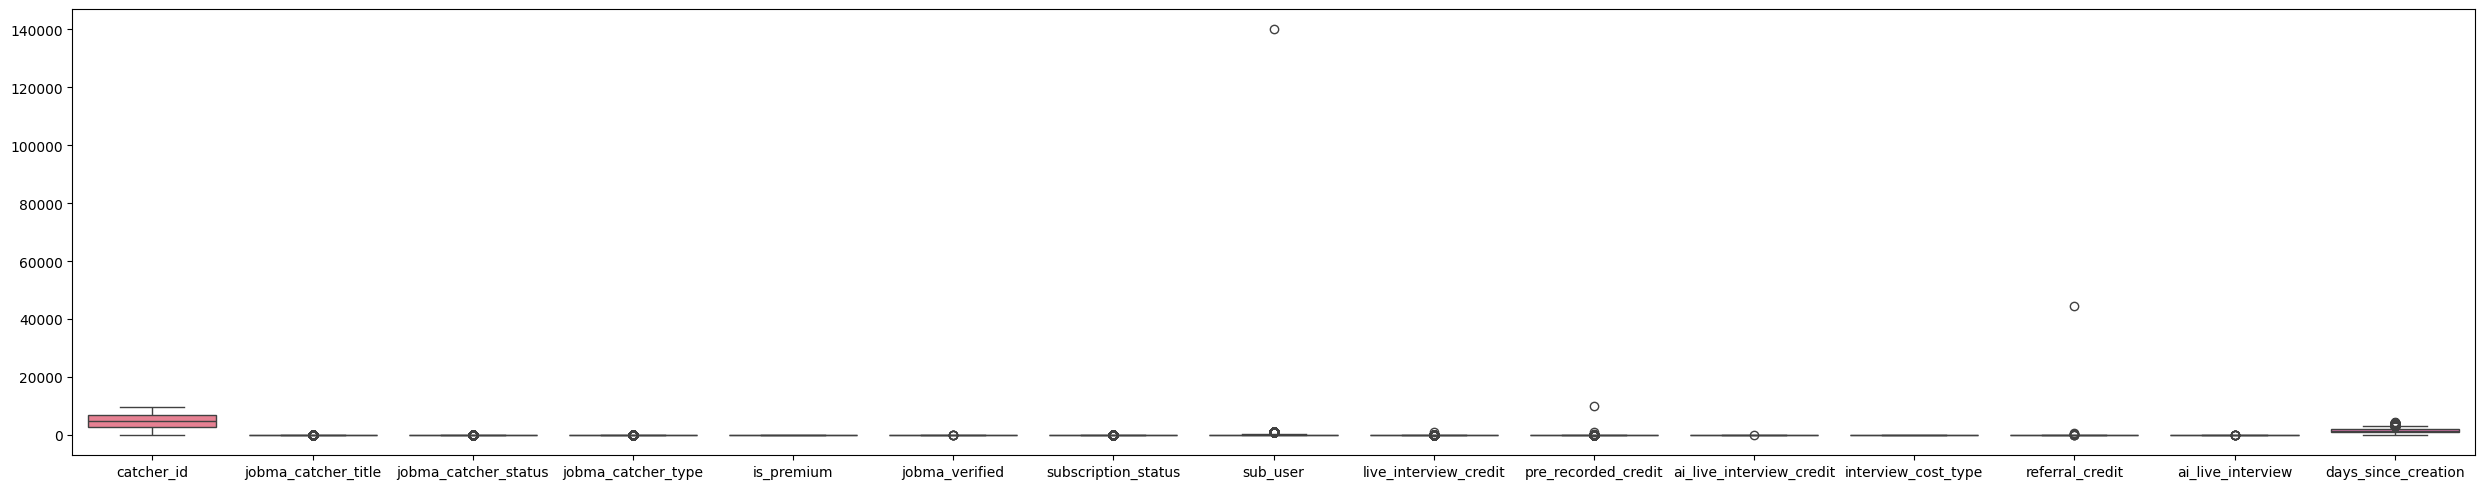

In [96]:
plt.figure(figsize=(25, 5))
sns.boxplot(data=df.iloc[:, :18])
plt.tight_layout()
plt.show()

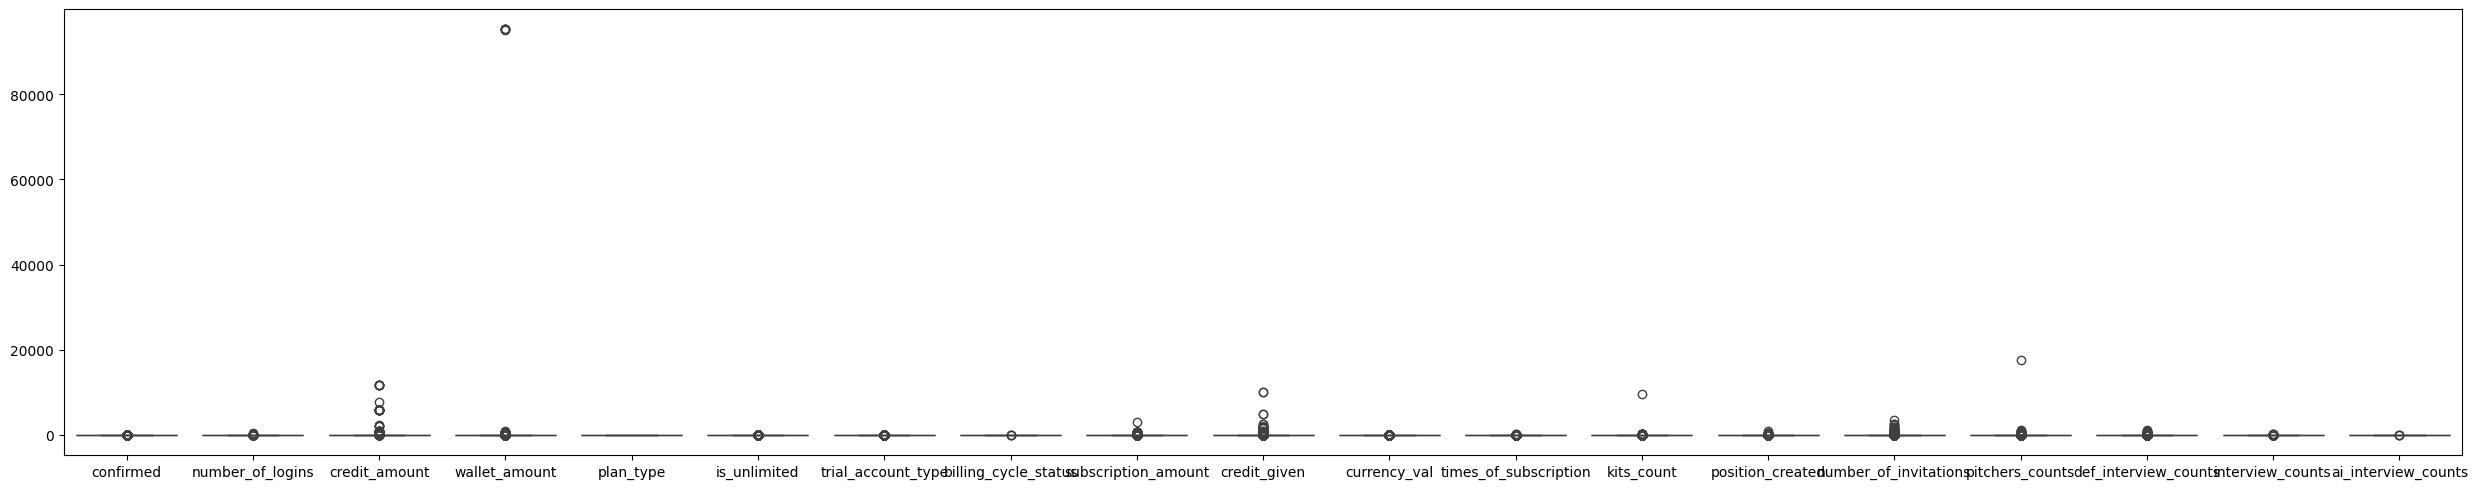

In [97]:
plt.figure(figsize=(25, 5))
sns.boxplot(data=df.iloc[:, 18:])
plt.tight_layout()
plt.show()


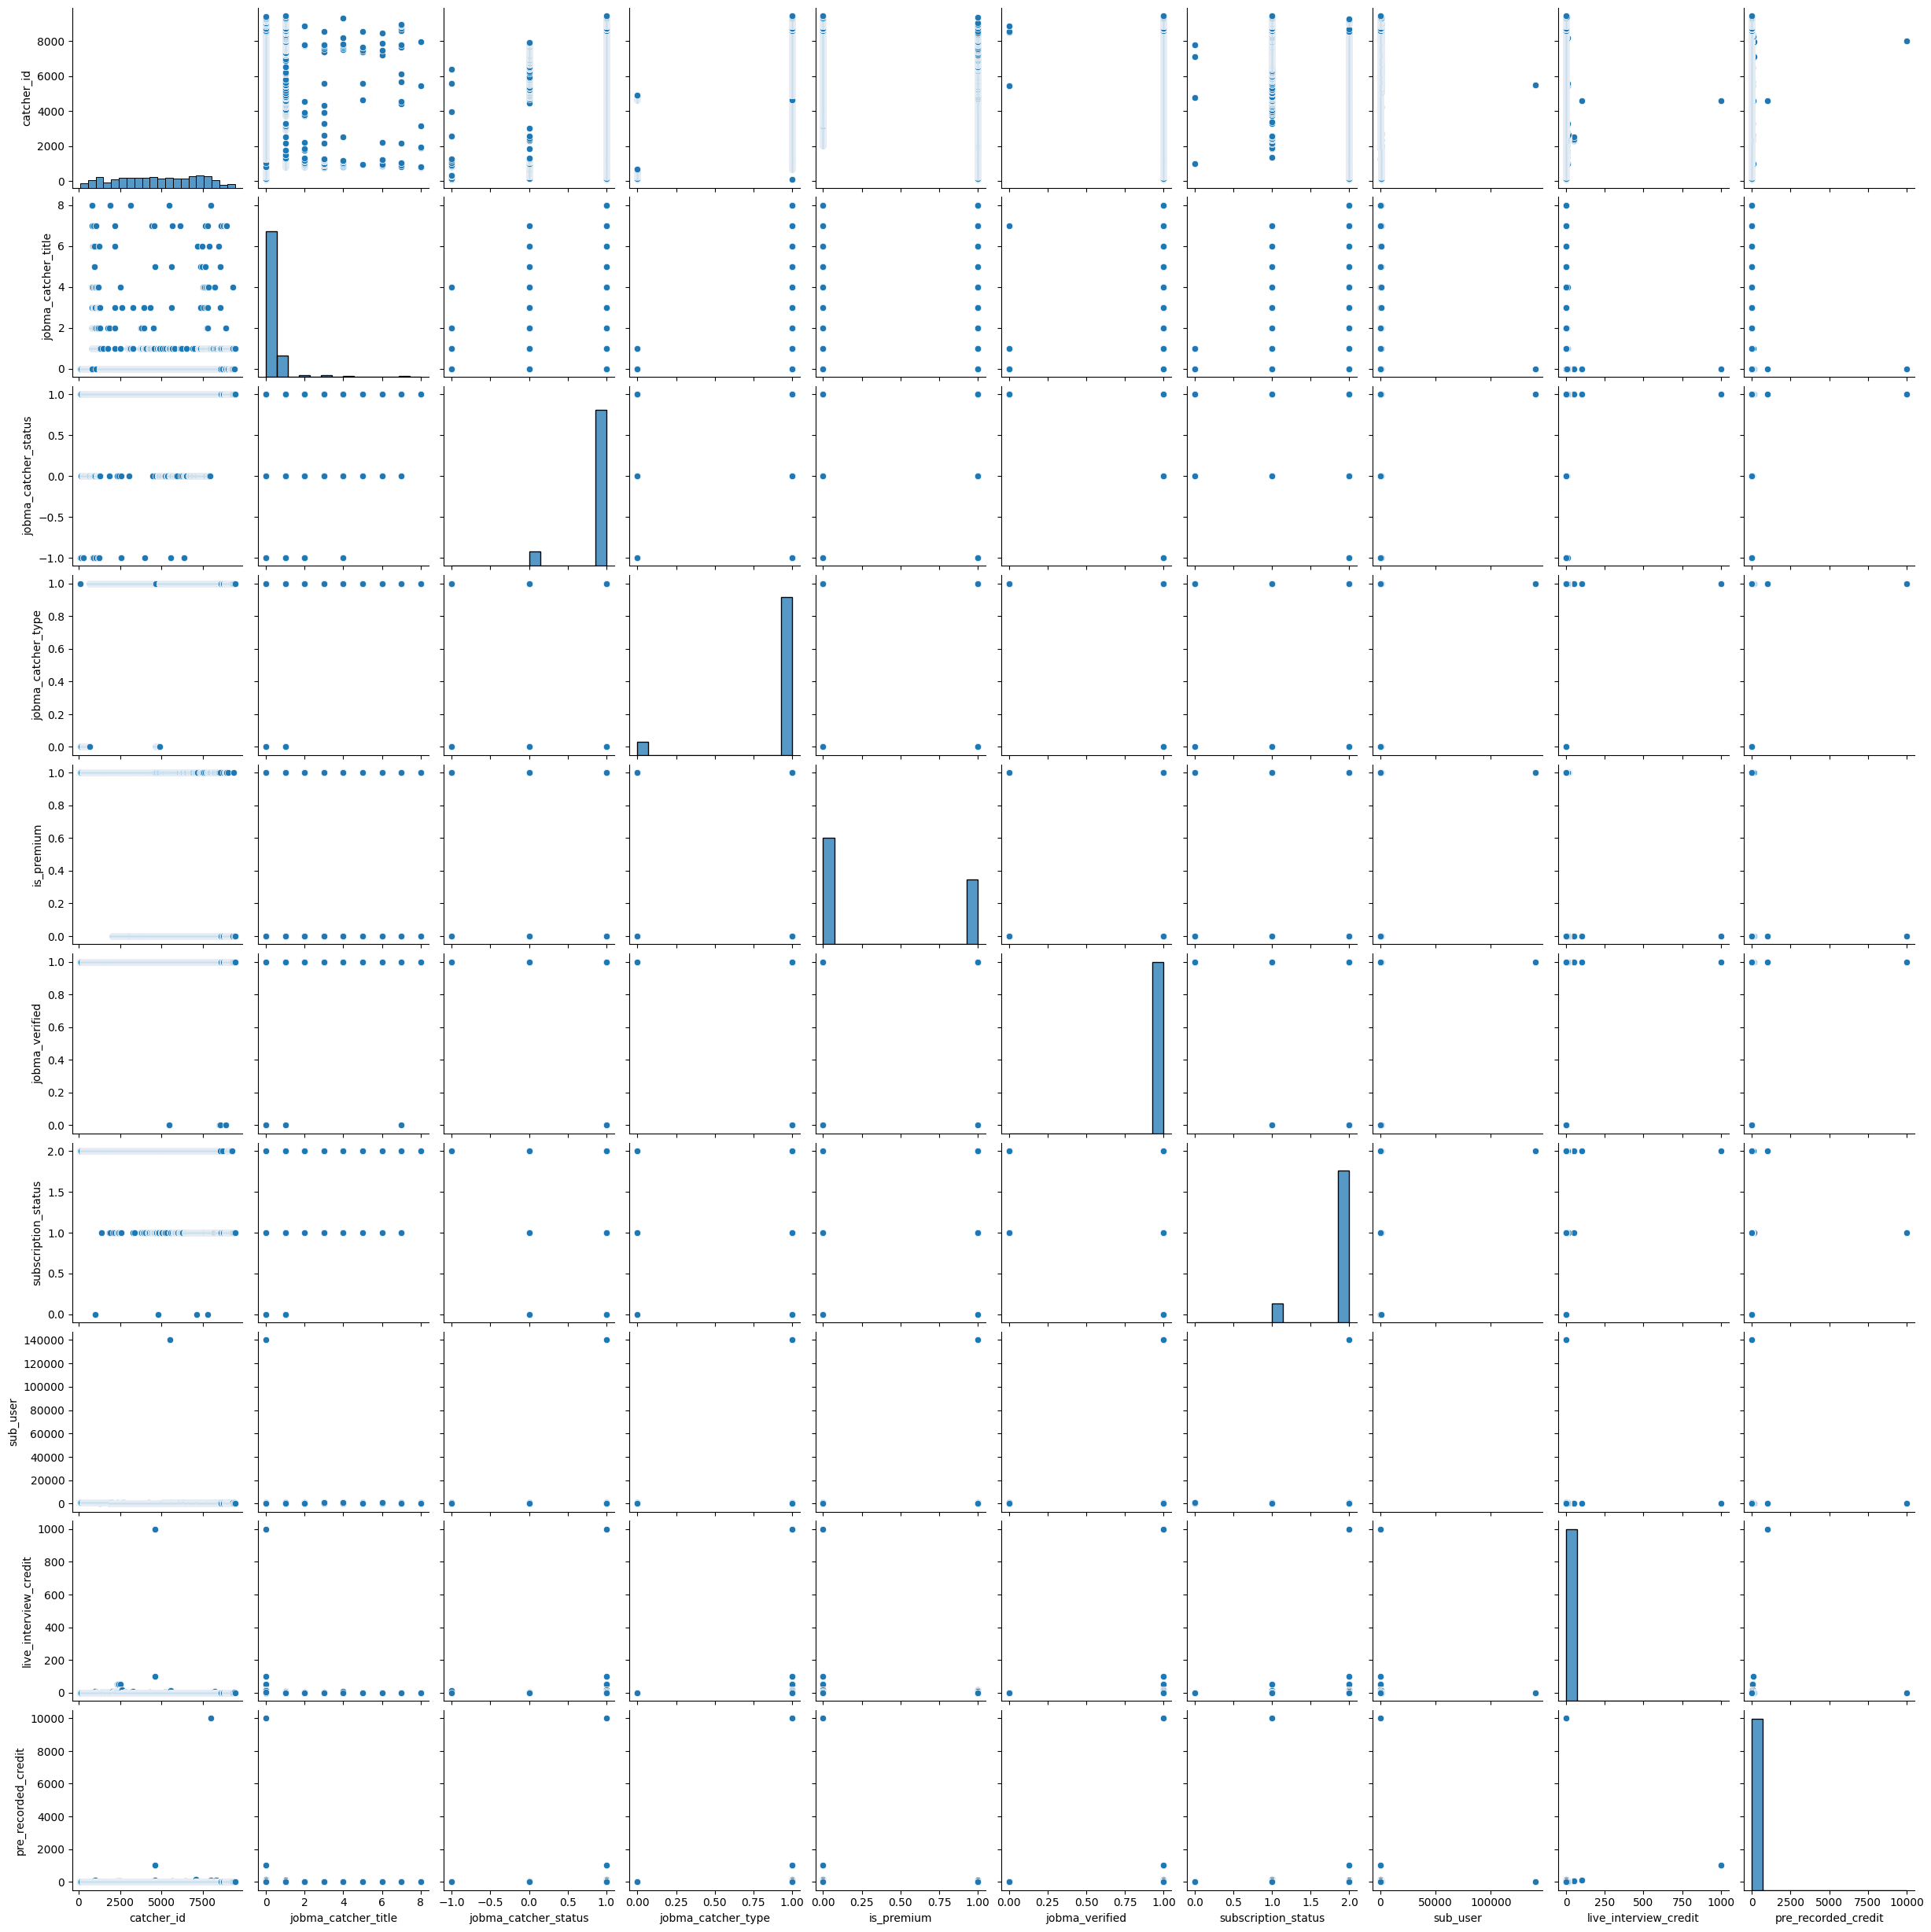

In [22]:
subset_cols = df.select_dtypes(include=['float64', 'int64']).columns[:10]
sns.pairplot(df[subset_cols], hue=None)
plt.show()

<Axes: xlabel='jobma_catcher_status', ylabel='count'>

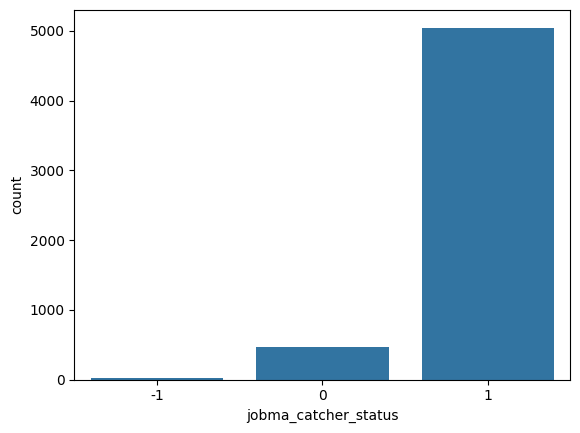

In [24]:
sns.countplot(x=df['jobma_catcher_status'])

<Axes: xlabel='jobma_catcher_otype', ylabel='count'>

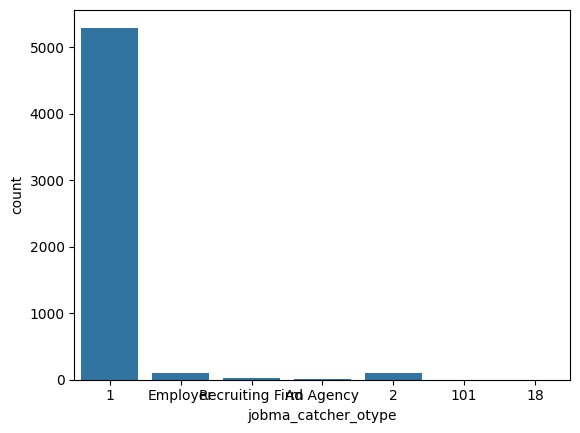

In [25]:
sns.countplot(x=df['jobma_catcher_otype'])

<Axes: xlabel='jobma_verified', ylabel='count'>

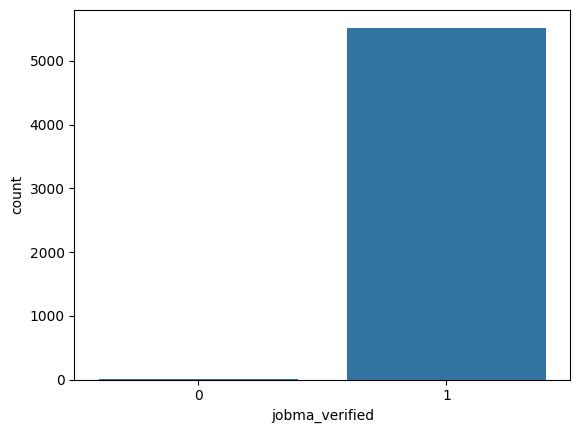

In [26]:
sns.countplot(x=df['jobma_verified'])

<Axes: xlabel='subscription_status', ylabel='count'>

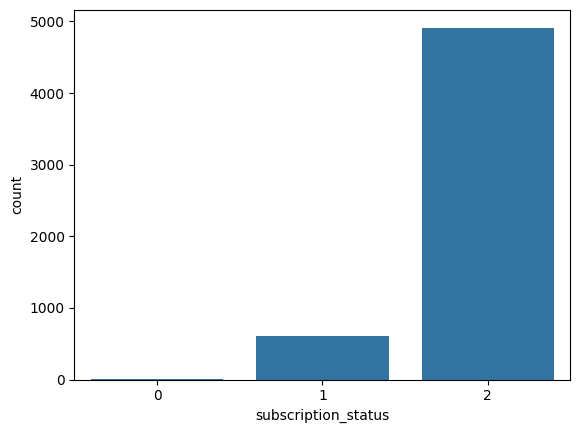

In [27]:
sns.countplot(x=df['subscription_status'])

<Axes: xlabel='company_size', ylabel='count'>

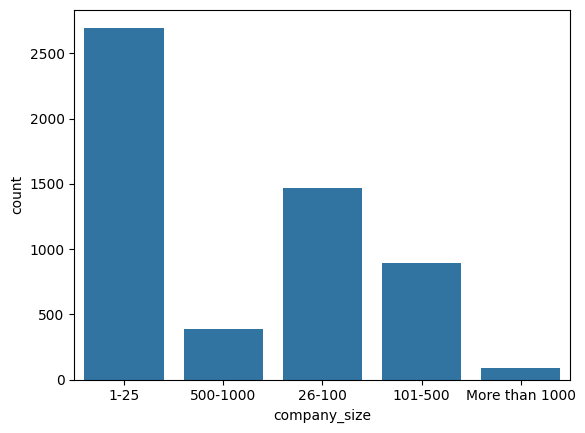

In [28]:
sns.countplot(x=df['company_size'])

<Axes: xlabel='plan_type', ylabel='count'>

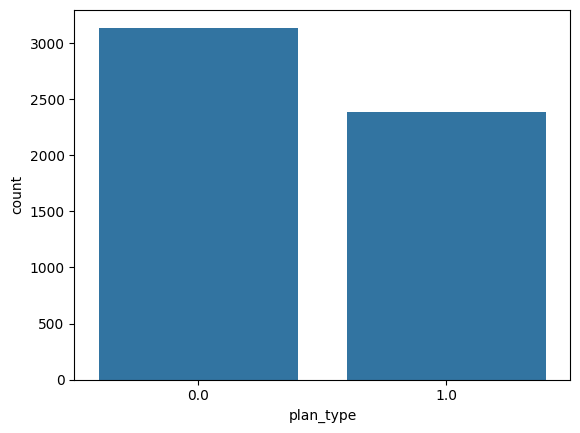

In [29]:
sns.countplot(x=df['plan_type'])

<Axes: xlabel='is_unlimited', ylabel='count'>

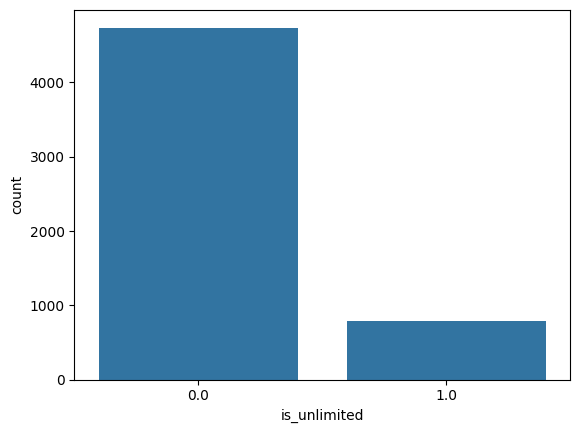

In [30]:
sns.countplot(x=df['is_unlimited'])

<Axes: xlabel='confirmed', ylabel='count'>

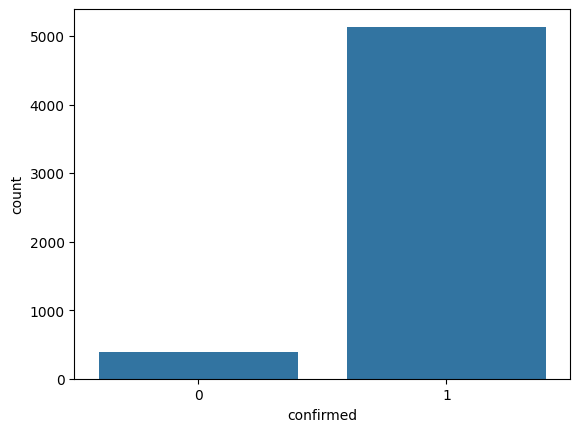

In [31]:
sns.countplot(x=df['confirmed'])

<Axes: xlabel='interview_cost_type', ylabel='count'>

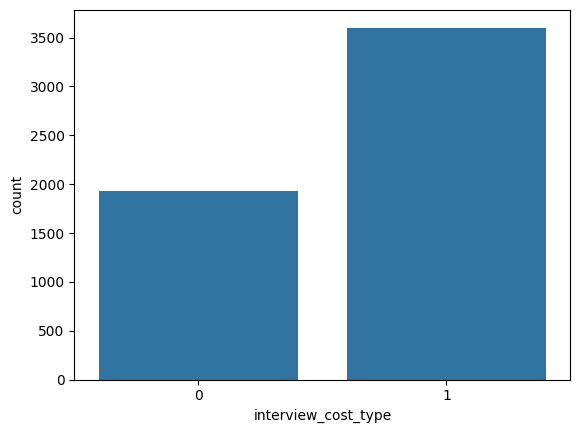

In [32]:
sns.countplot(x=df['interview_cost_type'])

<Axes: xlabel='wallet_amount', ylabel='Count'>

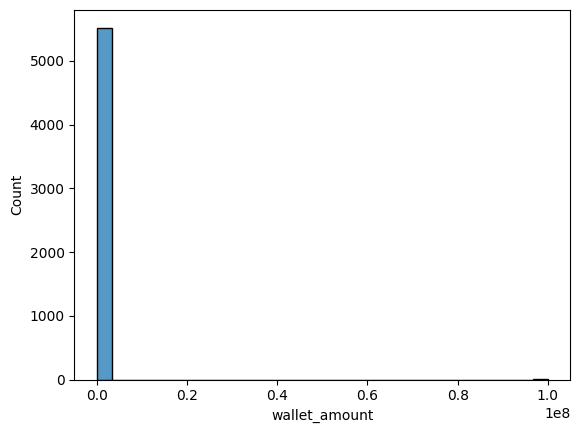

In [33]:
sns.histplot(df['wallet_amount'], bins=30)

<Axes: xlabel='subscription_amount', ylabel='Count'>

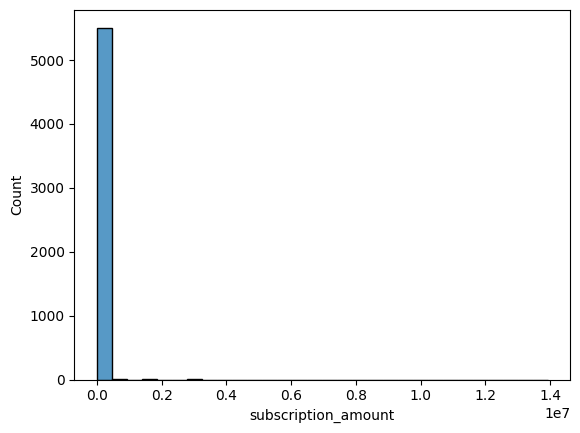

In [34]:
sns.histplot(df['subscription_amount'], bins=30)

<Axes: xlabel='days_since_creation', ylabel='Count'>

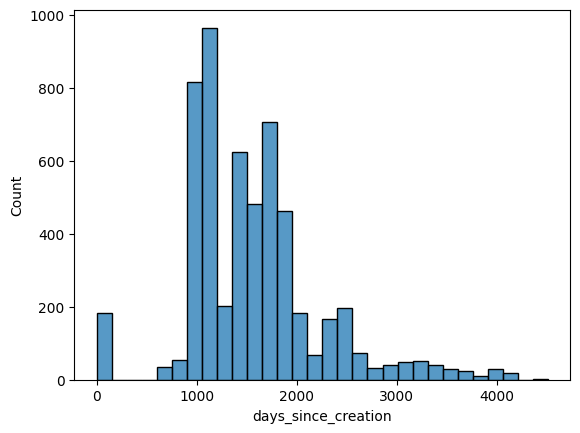

In [35]:
sns.histplot(df['days_since_creation'], bins=30)

<Axes: xlabel='pitchers_counts', ylabel='Count'>

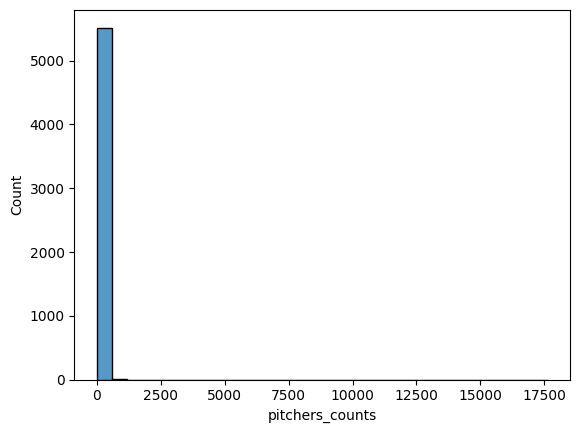

In [36]:
sns.histplot(df['pitchers_counts'], bins=30)

<Axes: xlabel='number_of_logins', ylabel='Count'>

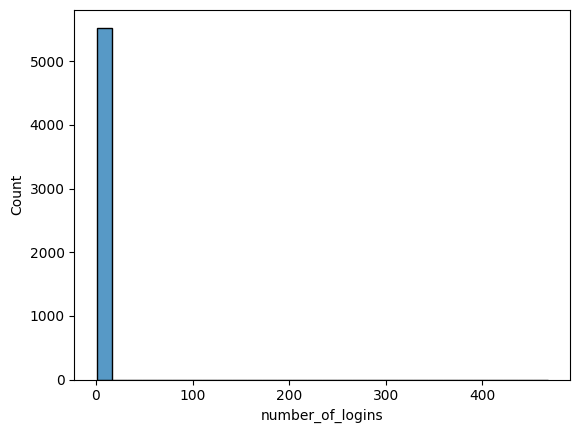

In [37]:
sns.histplot(df['number_of_logins'], bins=30)

<Axes: xlabel='kits_count', ylabel='Count'>

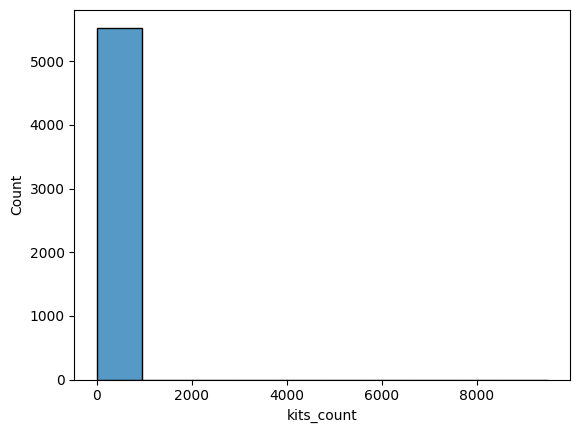

In [38]:
sns.histplot(df['kits_count'], bins=10)

<Axes: xlabel='position_created', ylabel='Count'>

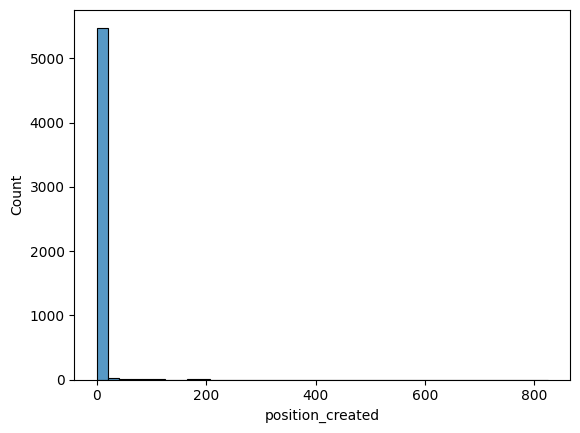

In [39]:
sns.histplot(df['position_created'], bins=40)

<Axes: xlabel='company_size', ylabel='wallet_amount'>

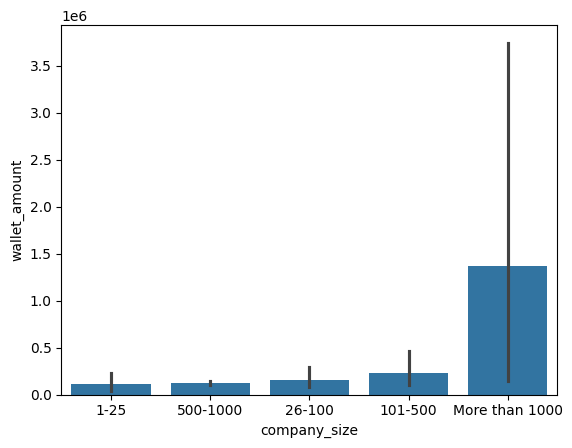

In [40]:
sns.barplot(x='company_size', y='wallet_amount', data=df)

<Axes: xlabel='company_size', ylabel='wallet_amount'>

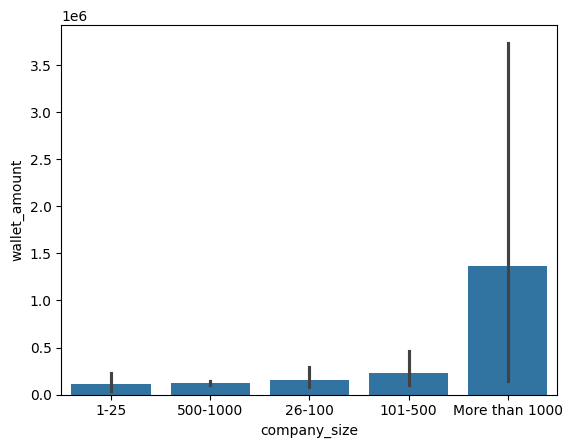

In [41]:
sns.barplot(x='company_size', y='wallet_amount', data=df)

<Axes: xlabel='subscription_amount', ylabel='is_premium'>

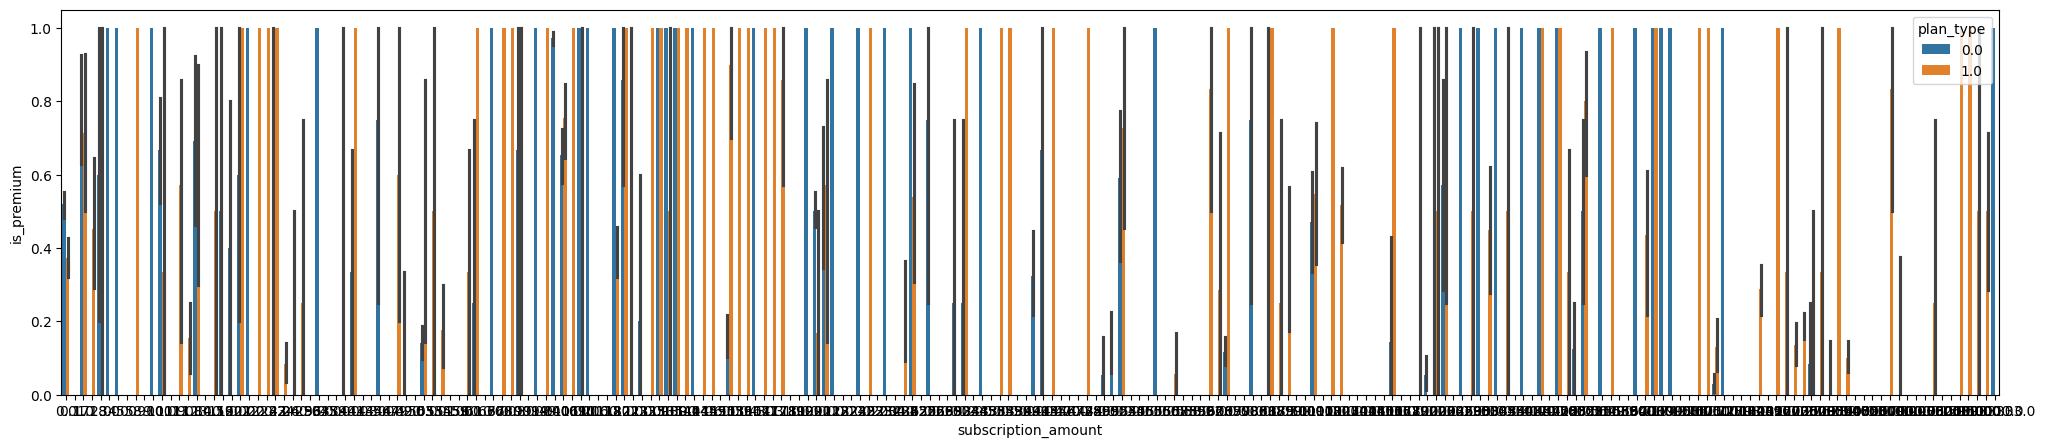

In [42]:
plt.figure(figsize=(25, 5))
sns.barplot(x='subscription_amount', y='is_premium', hue='plan_type', data=df)

<Axes: xlabel='subscription_bin', ylabel='is_premium'>

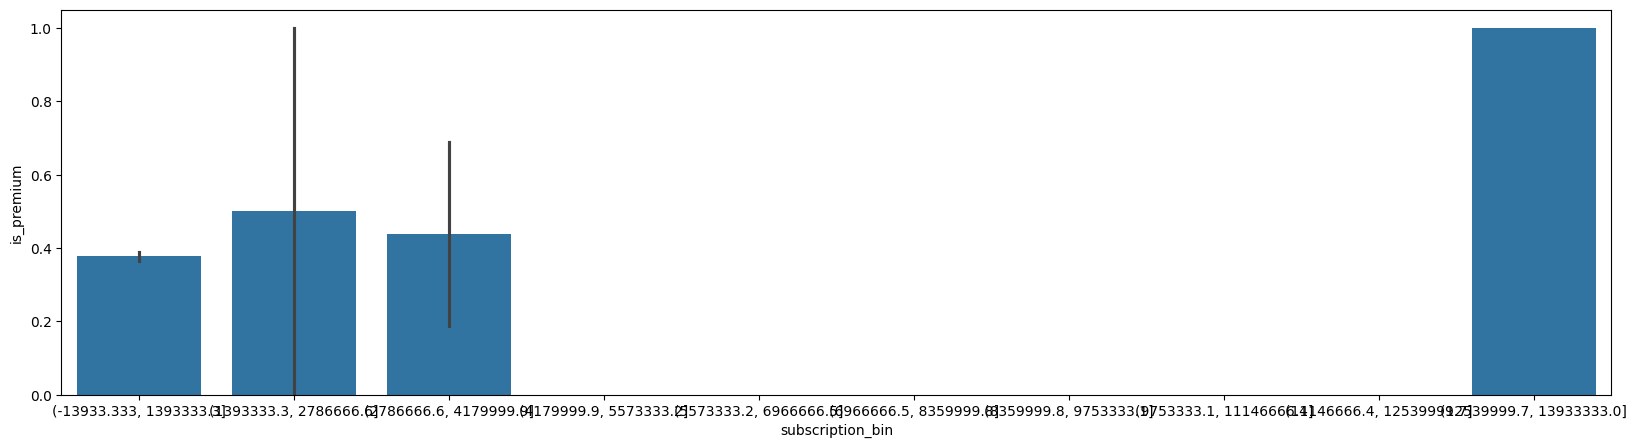

In [43]:
df['subscription_bin'] = pd.cut(df['subscription_amount'], bins=10)
plt.figure(figsize=(20,5))
sns.barplot(x='subscription_bin', y='is_premium', data=df)

<Axes: xlabel='is_premium', ylabel='wallet_amount'>

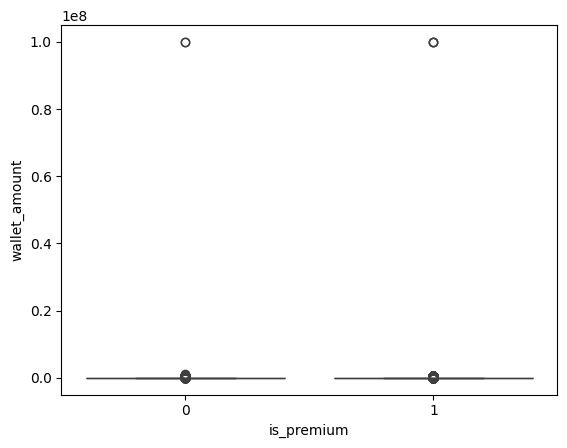

In [44]:
sns.boxplot(x='is_premium', y='wallet_amount', data=df)

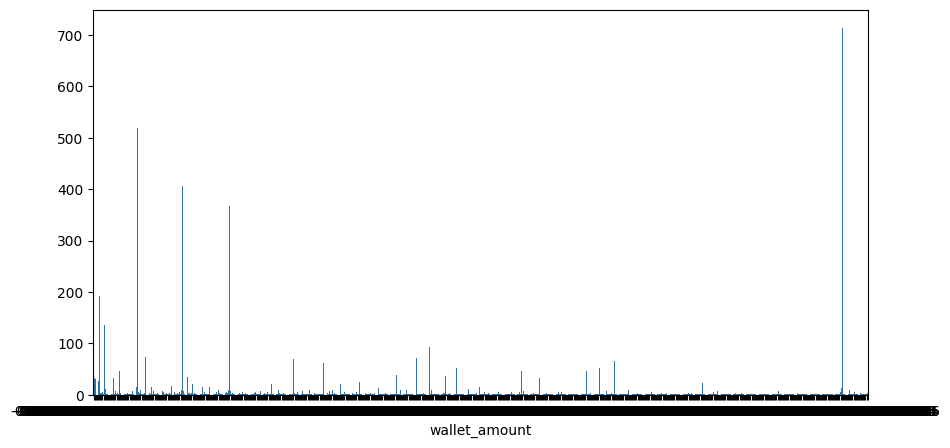

In [103]:
wallet_counts = df['wallet_amount'].value_counts().sort_index()
plt.figure(figsize=(10,5))
sns.barplot(x=wallet_counts.index, y=wallet_counts.values)
plt.show()

<Axes: >

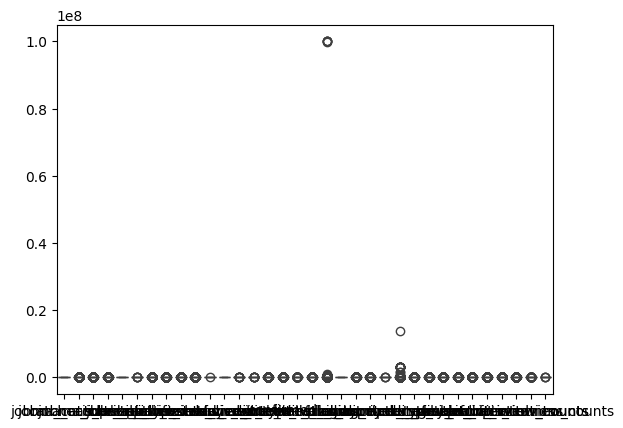

In [47]:
sns.boxplot(df)

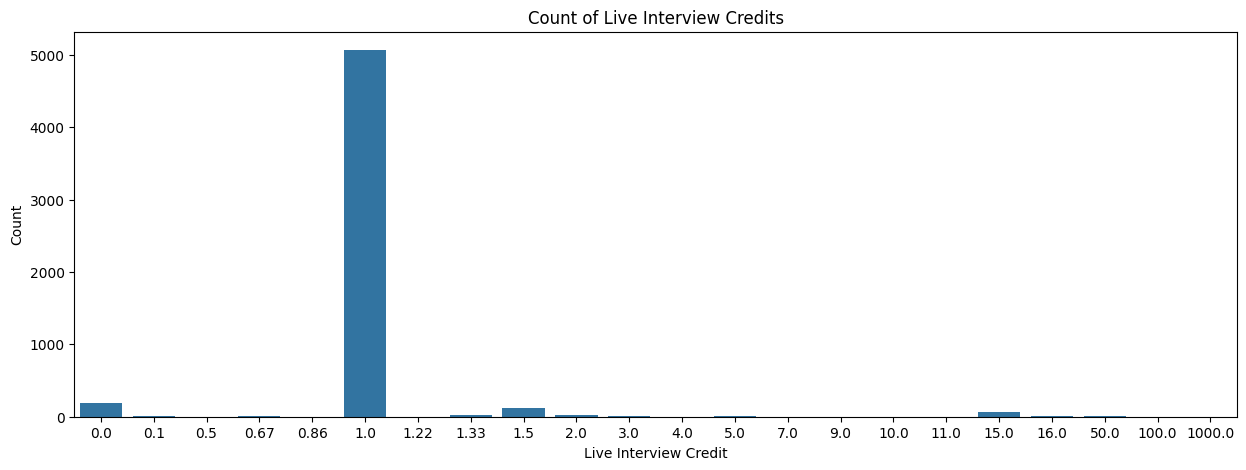

In [53]:
plt.figure(figsize=(15,5))
sns.countplot(x='live_interview_credit', data=df)
plt.title('Count of Live Interview Credits')
plt.xlabel('Live Interview Credit')
plt.ylabel('Count')
plt.show()

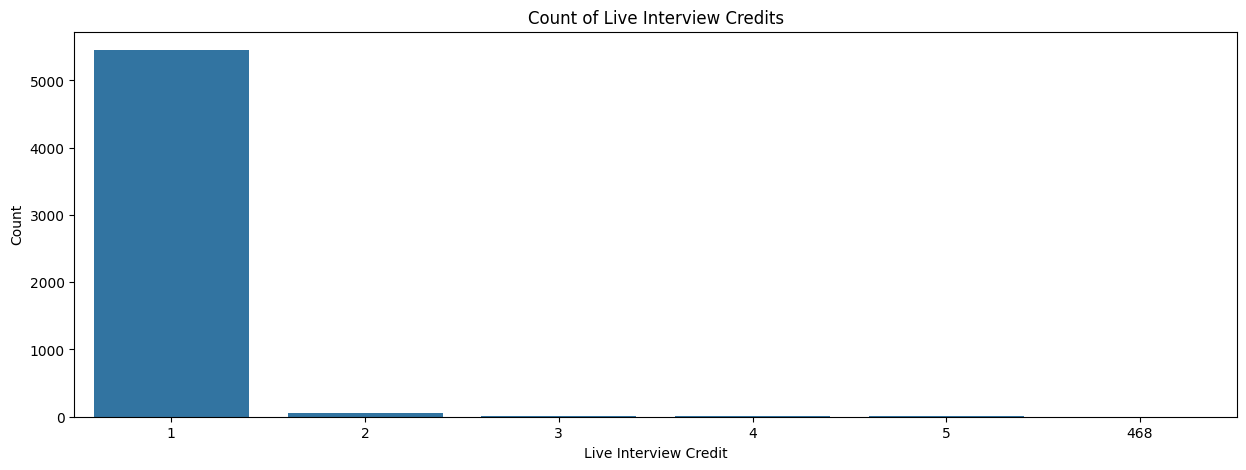

In [54]:
plt.figure(figsize=(15,5))
sns.countplot(x='number_of_logins', data=df)
plt.title('Count of Live Interview Credits')
plt.xlabel('Live Interview Credit')
plt.ylabel('Count')
plt.show()

# Boxplot for checking the extreme outliers

<Axes: >

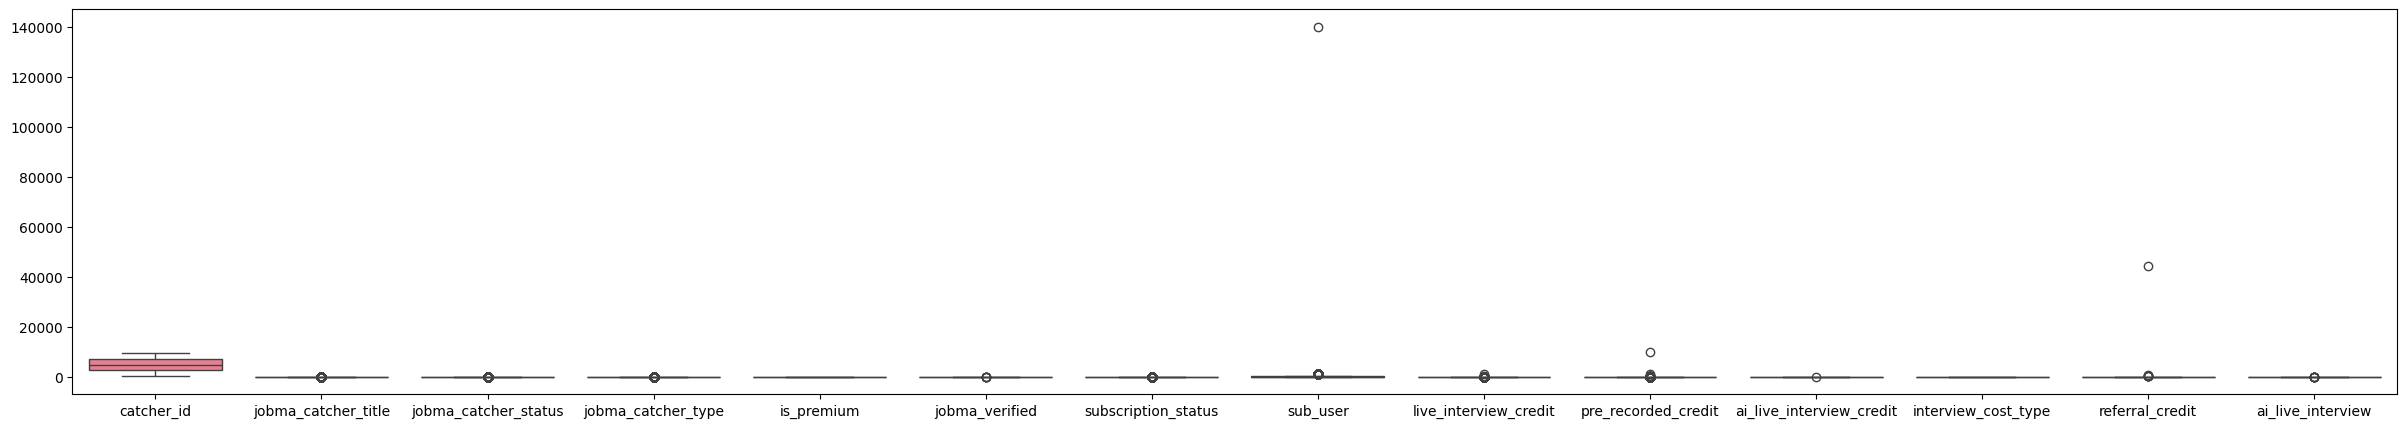

In [55]:
plt.figure(figsize=(30,5))
sns.boxplot(df.iloc[:, :17])

<Axes: >

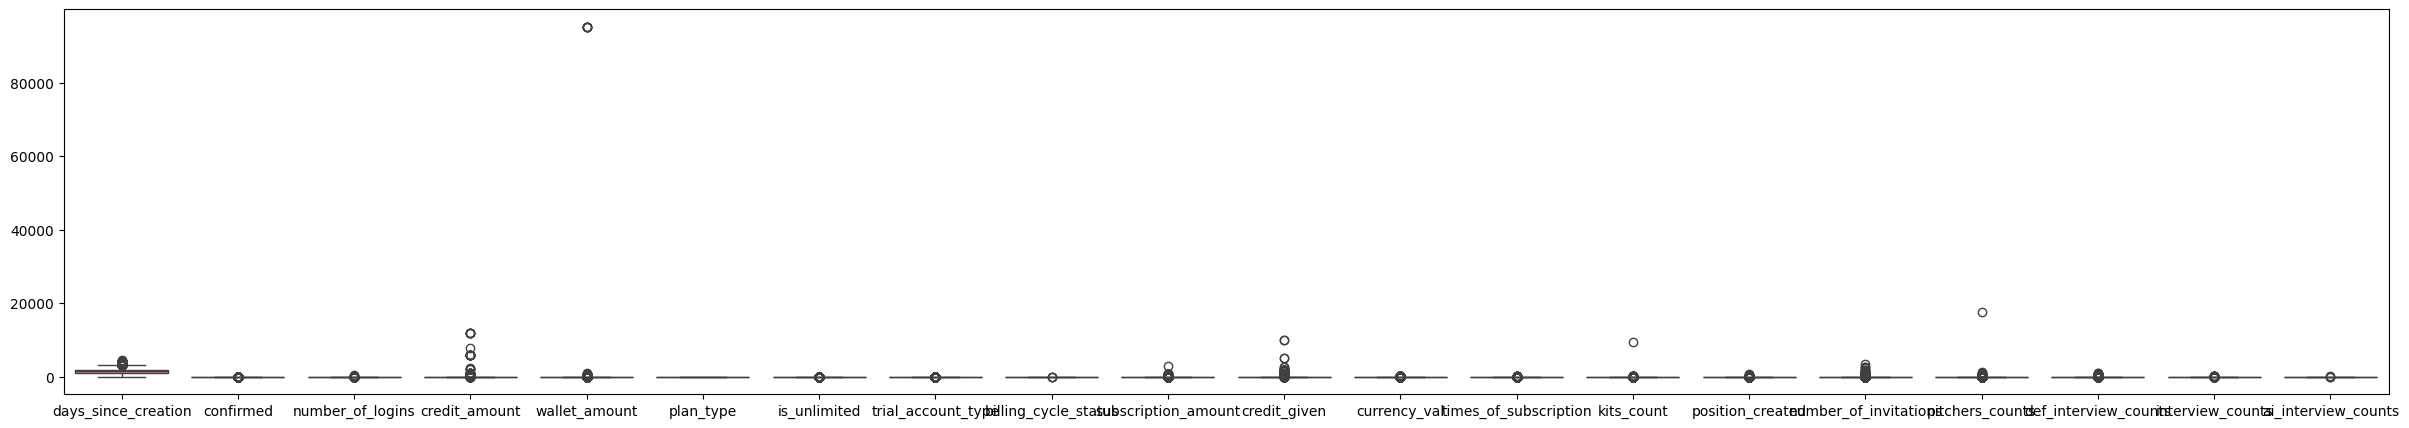

In [56]:
plt.figure(figsize=(30,5))
sns.boxplot(df.iloc[:, 17:])

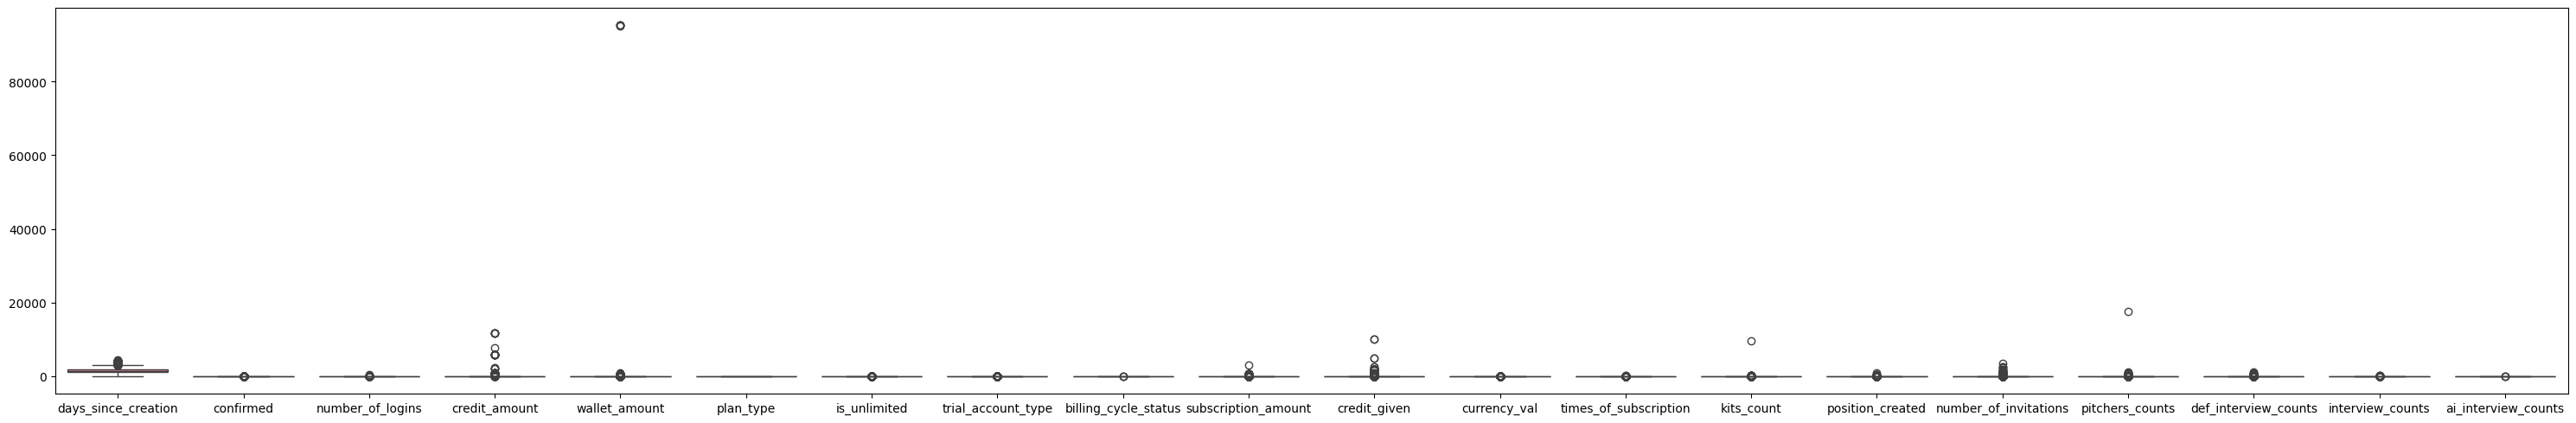

In [57]:
plt.figure(figsize=(30, 5))
sns.boxplot(df.iloc[:, 17:])
plt.tight_layout()
plt.show()